# An Informed Approach for Nature Based Projects in Regional Areas: Utilising Socio-Ecological Technologies and Local Knowledge to Improve Mental Health, Clean Up Emerging Pollutants and Deliver Climate Change Resilience

## Setting Up the Conda Environment
To recreate the Conda environment used in this project within Linux run:


### For **Linux/macO/WindowsS** users:
```bash
conda env create -f onehealth_environment.yml  # Ensure the filename is correct (check for typos)
conda activate onehealth_environment



### Importing Packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from functools import reduce
from scipy.stats import f_oneway, shapiro, levene, kruskal, spearmanr, shapiro, zscore
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.oneway import anova_oneway
from scikit_posthocs import posthoc_dunn


## Data Collection and Processing
Cleaning and merging of data

### Data Preprocessing

In [2]:
# Index for LGAs
lga_df = pd.read_csv("Data/2021CensusNSWLGAData/australian_census_2021_local_government_areas.csv")

# Extract unique LGA codes and names, excluding any trailing null/invalid values
lga_codes = lga_df['LGA_CODE_2021'].unique()[:-1]  # Exclude last element which is not a number
lga_names = lga_df['LGA_NAME_2021'].unique()

# Convert codes to integers and filter for NSW (codes < 20000)
nsw_codes = [int(code) for code in lga_codes]
nsw_codes = [code for code in nsw_codes if code < 20000]

# Format codes with 'LGA' prefix
formatted_codes = [f"LGA{code}" for code in nsw_codes]

# Get corresponding names for NSW LGAs
nsw_names = lga_names[:len(formatted_codes)]

# Create and return the index DataFrame
lga_index_health = pd.DataFrame({
    "LGA_CODE_2021": formatted_codes,
    "LGA_NAME_2021": nsw_names})

# Create new DataFrame with cleaned names
lga_index_crime = pd.DataFrame({
    'LGA_CODE_2021': lga_index_health['LGA_CODE_2021'],
    'LGA_NAME_2021': lga_index_health['LGA_NAME_2021'].str.replace(r"\s*\(NSW\)", "", regex=True)})

/tmp/ipykernel_9839/3149445699.py:2: DtypeWarning: Columns (0,1,3) have mixed types. Specify dtype option on import or set low_memory=False.
  lga_df = pd.read_csv("Data/2021CensusNSWLGAData/australian_census_2021_local_government_areas.csv")


#### Crime Data

In [3]:
# Importing the crime data
df_crime = pd.read_csv("Data/nsw_lga_offence_data_by_month_1995_2024.csv", 
                             index_col=[0, 1, 2])
# Filtering for the year 2021
df_crime = df_crime.loc[:, df_crime.columns.str.contains("2021")]

# Replace 'Subcategory' index name 'Offence category' name index name when NaN.
df_crime_modified = df_crime.copy()
df_crime_modified.index = df_crime_modified.index.map(lambda x: (x[0], x[1], x[1] if pd.isna(x[2]) else x[2]))

# Sum the Subcategory crime incidents for 2021
df_crime_modified = df_crime_modified.droplevel("Offence category")
df_crime_modified = df_crime_modified.sum(axis="columns")

# Unstack Subcategory to select crimes of interest as columns
df_crime_modified = df_crime_modified.unstack(level="Subcategory")
df_crime_modified = df_crime_modified[["Domestic violence related assault", 
                               "Non-domestic violence related assault",
                               "Assault Police",
                               "Sexual assault",
                               "Sexual touching, sexual act and other sexual offences", 
                               "Intimidation, stalking and harassment"]]

# Rename the index name for LGA for further processing
df_crime_modified = df_crime_modified.rename(index={"LGA":"LGA_NAME_2021"})
df_crime_modified.index.name = "LGA_NAME_2021"

# Sum the values and create new index entry 'Unincorporated NSW'
df_crime_modified.loc['Unincorporated NSW'] = df_crime_modified.loc['Unincorporated Far West'] + df_crime_modified.loc['Lord Howe Island']

# Drop the old index entries
df_crime_modified = df_crime_modified.drop(['Unincorporated Far West', 'Lord Howe Island'])

# Prepare and Merge the Index with LGA Codes
df_crime_modified.rename(index={'Cootamundra-Gundagai': 'Cootamundra-Gundagai Regional'}, inplace=True)
df_crime_modified = df_crime_modified.merge(lga_index_crime, how='left', on='LGA_NAME_2021')

In [4]:
df_crime_modified

,LGA_NAME_2021,Domestic violence related assault,Non-domestic violence related assault,Assault Police,Sexual assault,"Sexual touching, sexual act and other sexual offences","Intimidation, stalking and harassment",LGA_CODE_2021
0,Albury,405,340,41,75,79,516,LGA10050
1,Armidale Regional,237,200,6,75,54,219,LGA10180
2,Ballina,147,126,9,61,42,144,LGA10250
3,Balranald,7,6,0,0,1,6,LGA10300
4,Bathurst Regional,335,281,24,77,87,426,LGA10470
...,...,...,...,...,...,...,...,...
125,Wollondilly,146,82,5,38,46,196,LGA18400
126,Wollongong,652,708,82,188,196,782,LGA18450
127,Woollahra,102,98,6,53,35,138,LGA18500
128,Yass Valley,36,29,2,11,6,45,LGA18710


#### Population and Health Data

In [5]:
# Importing the census data on health and the LGA names
census_04a_df = pd.read_csv("Data/2021CensusNSWLGAData/2021 Census GCP Local Government Areas for NSW/2021Census_G04A_NSW_LGA.csv")
census_04b_df = pd.read_csv("Data/2021CensusNSWLGAData/2021 Census GCP Local Government Areas for NSW/2021Census_G04B_NSW_LGA.csv")
census_19a_df = pd.read_csv("Data/2021CensusNSWLGAData/2021 Census GCP Local Government Areas for NSW/2021Census_G19A_NSW_LGA.csv")
census_19b_df = pd.read_csv("Data/2021CensusNSWLGAData/2021 Census GCP Local Government Areas for NSW/2021Census_G19B_NSW_LGA.csv")
#census_19c_df = pd.read_csv("MaterialsAndMethods/Data/2021CensusNSWLGAData/NSWLGACensus2021HealthData/2021Census_G19C_NSW_LGA.csv")

In [6]:
# Merge the census data on the LGA_CODE_2021
data_frames = [census_04a_df, census_04b_df, census_19a_df, census_19b_df]
census_nsw_pop_health = reduce(lambda  left,right: pd.merge(left,right,on=['LGA_CODE_2021'],
                                            how='outer'), data_frames)

In [7]:
# Creating the population groups for assessment
male_young_pop = [f"Age_yr_{i}_{i+4}_M" for i in range(0, 35, 5)]
male_older_pop = [f"Age_yr_{i}_{i+4}_M" for i in range(35, 100, 5)] + ["Age_yr_100_yr_over_M"]
female_young_pop = [f"Age_yr_{i}_{i+4}_F" for i in range(0, 35, 5)]
female_older_pop = [f"Age_yr_{i}_{i+4}_F" for i in range(35, 100, 5)] + ["Age_yr_100_yr_over_F"]

# Creating the mental health age groups for assessment
male_young_mh = ['M_Mental_health_cond_0_14', 'M_Mental_health_cond_15_24', 'M_Mental_health_cond_25_34']
male_older_mh = ['M_Mental_health_cond_35_44',	'M_Mental_health_cond_45_54',	'M_Mental_health_cond_55_64',	'M_Mental_health_cond_65_74',	'M_Mental_health_cond_75_84',	'M_Mental_health_cond_85_over']
female_young_mh = ['F_Mental_health_cond_0_14', 'F_Mental_health_cond_15_24', 'F_Mental_health_cond_25_34']
female_older_mh = ['F_Mental_health_cond_35_44',	'F_Mental_health_cond_45_54',	'F_Mental_health_cond_55_64',	'F_Mental_health_cond_65_74',	'F_Mental_health_cond_75_84',	'F_Mental_health_cond_85_over']

In [8]:
# Create the new summed population categories
census_nsw_pop_health['M_total_pop_0_34'] = census_nsw_pop_health[male_young_pop].sum(axis=1)
census_nsw_pop_health['M_total_pop_35_85_over'] = census_nsw_pop_health[male_older_pop].sum(axis=1)
census_nsw_pop_health['F_total_pop_0_34'] = census_nsw_pop_health[female_young_pop].sum(axis=1)
census_nsw_pop_health['F_total_pop_35_85_over'] = census_nsw_pop_health[female_older_pop].sum(axis=1)

# Create the new summed mental health categories
census_nsw_pop_health['M_Mental_health_cond_0_34'] = census_nsw_pop_health[male_young_mh].sum(axis=1)
census_nsw_pop_health['M_Mental_health_cond_35_85_over'] = census_nsw_pop_health[male_older_mh].sum(axis=1)
census_nsw_pop_health['F_Mental_health_cond_0_34'] = census_nsw_pop_health[female_young_mh].sum(axis=1)
census_nsw_pop_health['F_Mental_health_cond_35_85_over'] = census_nsw_pop_health[female_older_mh].sum(axis=1)

# Filter for the categories of interest
census_nsw_pop_health = census_nsw_pop_health.loc[:, ['Tot_P', 
                                                      'M_Mental_health_cond_0_34',
                                                      'M_Mental_health_cond_35_85_over', 
                                                      'F_Mental_health_cond_0_34', 
                                                      'F_Mental_health_cond_35_85_over',
                                                      'M_total_pop_0_34',
                                                      'M_total_pop_35_85_over',
                                                      'F_total_pop_0_34',
                                                      'F_total_pop_35_85_over',
                                                      'LGA_CODE_2021']]

In [9]:
# Since the census data only has the code merge with the LGA code
census_nsw_pop_health = census_nsw_pop_health.merge(lga_index_health, how='left', on='LGA_CODE_2021')

#### Preparing Crime and Mental Health Rates

In [10]:
# Merging the Census Data with the Crime Data
df_crime_health = df_crime_modified.merge(census_nsw_pop_health, on="LGA_CODE_2021")
df_crime_health = df_crime_health.drop(labels=['LGA_NAME_2021_x'], axis=1)
df_crime_health = df_crime_health.rename(columns={"LGA_NAME_2021_y":"LGA_NAME_2021"})
df_crime_health = df_crime_health.set_index(["LGA_NAME_2021", "LGA_CODE_2021"])

In [11]:
# Calculating the crime rates
df_crime_rates = df_crime_health[["Domestic violence related assault", 
                               "Non-domestic violence related assault",
                               "Assault Police",
                               "Sexual assault",
                               "Sexual touching, sexual act and other sexual offences", 
                               "Intimidation, stalking and harassment"]].div(df_crime_health['Tot_P'], axis=0)

In [12]:
# Calculating the mental health rates
rate_columns = {
    'M_Mental_health_rate_0_34': 'M_Mental_health_cond_0_34',
    'M_Mental_health_rate_35_85_over': 'M_Mental_health_cond_35_85_over',
    'F_Mental_health_rate_0_34': 'F_Mental_health_cond_0_34',
    'F_Mental_health_rate_35_85_over': 'F_Mental_health_cond_35_85_over'}


df_health_rates = pd.DataFrame()

for rate_col, cond_col in rate_columns.items():
    total_pop_col = cond_col.replace('Mental_health_cond', 'total_pop')
    df_health_rates[rate_col] = df_crime_health[cond_col] / df_crime_health[total_pop_col]

In [13]:
df_crime_health_rates = df_health_rates.merge(df_crime_rates, left_index=True, right_index=True)
df_crime_health_rates

,,M_Mental_health_rate_0_34,M_Mental_health_rate_35_85_over,F_Mental_health_rate_0_34,F_Mental_health_rate_35_85_over,Domestic violence related assault,Non-domestic violence related assault,Assault Police,Sexual assault,"Sexual touching, sexual act and other sexual offences","Intimidation, stalking and harassment"
LGA_NAME_2021,LGA_CODE_2021,,,,,,,,,,
Albury,LGA10050,0.071983,0.109088,0.130851,0.143902,0.007220,0.006061,0.000731,0.001337,0.001408,0.009199
Armidale Regional,LGA10180,0.065987,0.083152,0.115792,0.115668,0.008138,0.006867,0.000206,0.002575,0.001854,0.007520
Ballina,LGA10250,0.067368,0.094947,0.105814,0.119538,0.003175,0.002722,0.000194,0.001318,0.000907,0.003110
Balranald,LGA10300,0.024691,0.044515,0.055556,0.050691,0.003170,0.002717,0.000000,0.000000,0.000453,0.002717
Bathurst Regional,LGA10470,0.075743,0.094778,0.123931,0.139516,0.007689,0.006450,0.000551,0.001767,0.001997,0.009778
...,...,...,...,...,...,...,...,...,...,...,...
Wollondilly,LGA18400,0.051840,0.074279,0.089595,0.110521,0.002706,0.001520,0.000093,0.000704,0.000852,0.003632
Wollongong,LGA18450,0.063506,0.088954,0.118190,0.129863,0.003039,0.003300,0.000382,0.000876,0.000913,0.003645
Woollahra,LGA18500,0.036816,0.048311,0.074161,0.059787,0.001907,0.001832,0.000112,0.000991,0.000654,0.002580


####  Preparing Census Indexes & Council Classification

In [14]:
cols_interest = ["Index of Relative Socio-economic Disadvantage Score", 
                 "Index of Relative Socio-economic Advantage and Disadvantage Score", 
                 "Index of Economic Resources Score",
                 "Index of Education and Occupation Score"]

seifa_df = pd.read_csv("Data/250110_local_government_areas_indexes_seifa_2021_nsw.csv",
                       skiprows=5,
                       index_col=["LGA_CODE_2021","LGA_NAME_2021"])

In [15]:
# Return the indexes of interest.
seifa_df = seifa_df[cols_interest]
df_crime_health_seifa = seifa_df.merge(df_crime_health_rates, on="LGA_NAME_2021")

In [16]:
council_type_df = pd.read_csv("Data/250110_nsw_councils_group_and_type.csv",
                       index_col=["LGA_NAME_2021"])

In [17]:
# Evaluate the Difference in Index for Primary Dataset 
crime_health_seifa_index = df_crime_health_seifa.index
council_type_index = council_type_df.index
only_in_crime_health_seifa_index = crime_health_seifa_index.difference(council_type_index)
print("Only in Crime Health Seifa Index:", only_in_crime_health_seifa_index)

Only in Crime Health Seifa Index: Index(['Unincorporated NSW'], dtype='object', name='LGA_NAME_2021')


In [18]:
# Merge and export the merged dataframes
df_crime_health_seifa_council = df_crime_health_seifa.merge(council_type_df, on="LGA_NAME_2021")
df_crime_health_seifa_council.to_csv("250110_crime_health_seifa_council_data.csv")

In [19]:
# Rename the columns for better readability
df_crime_health_seifa_council = df_crime_health_seifa_council.rename(columns={
    'Index of Relative Socio-economic Disadvantage Score': 'Socio-economic Disadvantage',
    'Index of Relative Socio-economic Advantage and Disadvantage Score': 'Socio-economic Advantage/Disadvantage',
    'Index of Economic Resources Score': 'Economic Resources',
    'Index of Education and Occupation Score': 'Education and Occupation',
    'M_Mental_health_rate_0_34': 'Male Mental Health Rate (0-34)',
    'M_Mental_health_rate_35_85_over': 'Male Mental Health Rate (>35)',
    'F_Mental_health_rate_0_34': 'Female Mental Health Rate (0-34)',
    'F_Mental_health_rate_35_85_over': 'Female Mental Health Rate (>35)',
    'Domestic violence related assault': 'Domestic Violence Assault',
    'Non-domestic violence related assault': 'Non-domestic Violence Assault',
    'Assault Police': 'Assault on Police',
    'Sexual assault': 'Sexual Assault',
    'Sexual touching, sexual act and other sexual offences': 'Sexual Offences',
    'Intimidation, stalking and harassment': 'Stalking and Harassment'})
df_crime_health_seifa_council.head(10)

,Socio-economic Disadvantage,Socio-economic Advantage/Disadvantage,Economic Resources,Education and Occupation,Male Mental Health Rate (0-34),Male Mental Health Rate (>35),Female Mental Health Rate (0-34),Female Mental Health Rate (>35),Domestic Violence Assault,Non-domestic Violence Assault,Assault on Police,Sexual Assault,Sexual Offences,Stalking and Harassment,OLG Group,Council Type
LGA_NAME_2021,,,,,,,,,,,,,,,,
Albury,968,950,962,954,0.071983,0.109088,0.130851,0.143902,0.007220,0.006061,0.000731,0.001337,0.001408,0.009199,4,Regional Town/City
Armidale Regional,980,976,955,1010,0.065987,0.083152,0.115792,0.115668,0.008138,0.006867,0.000206,0.002575,0.001854,0.007520,4,Regional Town/City
Ballina,1015,996,1011,991,0.067368,0.094947,0.105814,0.119538,0.003175,0.002722,0.000194,0.001318,0.000907,0.003110,4,Regional Town/City
Balranald,960,934,970,915,0.024691,0.044515,0.055556,0.050691,0.003170,0.002717,0.000000,0.000000,0.000453,0.002717,9,Rural
Bathurst Regional,991,967,999,959,0.075743,0.094778,0.123931,0.139516,0.007689,0.006450,0.000551,0.001767,0.001997,0.009778,4,Regional Town/City
Bayside (NSW),1004,1044,966,1051,0.028677,0.055065,0.050046,0.078394,0.003579,0.002226,0.000257,0.000491,0.000502,0.003859,3,Metropolitan
Bega Valley,986,949,987,946,0.067494,0.093239,0.108700,0.127493,0.003478,0.003033,0.000195,0.000946,0.000974,0.003756,4,Regional Town/City
Bellingen,981,960,983,985,0.065884,0.090952,0.106343,0.130639,0.003773,0.004075,0.000075,0.001735,0.001962,0.003999,11,Large Rural
Berrigan,966,927,974,913,0.061429,0.093370,0.091938,0.132082,0.002654,0.004155,0.000231,0.000923,0.001039,0.005193,10,Large Rural


In [20]:
# For individual council type analysis, for example modify the Council Type
# For example "Metropolitan" or "Large Rural". Uncomment the line below. 
# df_crime_health_seifa_council = df_crime_health_seifa_council[df_crime_health_seifa_council['Council Type']=='Metropolitan']

## Exploratory Data Analysis (EDA)
* Summary statistics for key variables.
* Visualization of relationships (e.g. scatter plots, histograms, correlation matricies). 
* Insights from initial exploration

1. **Summary Statistics**
2. **Boxplots**
3. **Barcharts**
4. **Scatterplots**
5. **Statistical Significance and Post-Hoc Tests**

#### Summary Statistics 

In [21]:
# Summary statistics based on 'Council Type'
summary_by_council_type = df_crime_health_seifa_council.groupby('Council Type').describe()

# Export the results
summary_by_council_type.to_csv('250206_rates_of_mental_health_crime_and_seifa_by_council_type.csv')

# Display the results
summary_by_council_type

Socio-economic Disadvantage                                     \
                                   count     mean        std    min     25%   
Council Type                                                                  
Metropolitan                        25.0  1032.76  76.428223  814.0  1004.0   

                                     Socio-economic Advantage/Disadvantage  \
                 50%     75%     max                                 count   
Council Type                                                                 
Metropolitan  1057.0  1092.0  1110.0                                  25.0   

                       ... Stalking and Harassment           OLG Group        \
                 mean  ...                     75%       max     count  mean   
Council Type           ...                                                     
Metropolitan  1085.92  ...                0.003981  0.006885      25.0  2.68   

                                                 
                   std  min  25%  50%  75%  max  
Council Type                                     
Metropolitan  0.556776  1.0  2.0  3.0  3.0  3.0  

[1 rows x 120 columns]

#### Boxplots

In [22]:
# Data Preparation

# Define the columns to plot
indexes = ['Economic Resources', 
           'Education and Occupation',
           'Council Type']

mental_health = ['Male Mental Health Rate (0-34)', 
                 'Male Mental Health Rate (>35)', 
                 'Female Mental Health Rate (0-34)', 
                 'Female Mental Health Rate (>35)',
                 'Council Type']

violent_crime = ['Domestic Violence Assault', 
                 'Non-domestic Violence Assault', 
                 'Sexual Assault', 'Sexual Offences', 
                 'Stalking and Harassment',
                 'Council Type']

# Melt the dataframe for the selected columns
df_indexes_melted = df_crime_health_seifa_council[indexes].reset_index().melt(id_vars=["LGA_NAME_2021",
                                                                                       "Council Type"], 
                                                                                       var_name="Index Type", 
                                                                                       value_name="Index Value")

df_mental_health_melted = df_crime_health_seifa_council[mental_health].reset_index().melt(id_vars=["LGA_NAME_2021",
                                                                                       "Council Type"], 
                                                                                       var_name="Mental Health Group", 
                                                                                       value_name="Mental Health Rate")

df_violent_crime_melted = df_crime_health_seifa_council[violent_crime].reset_index().melt(id_vars=["LGA_NAME_2021",
                                                                                       "Council Type"], 
                                                                                       var_name="Crime Type", 
                                                                                       value_name="Crime Rate")

# Convert rates to percentages
df_mental_health_melted["Mental Health Rate"] = df_mental_health_melted["Mental Health Rate"] * 100
df_violent_crime_melted["Crime Rate"] = df_violent_crime_melted["Crime Rate"] * 100

In [23]:
df_mental_health_melted

,LGA_NAME_2021,Council Type,Mental Health Group,Mental Health Rate
0,Bayside (NSW),Metropolitan,Male Mental Health Rate (0-34),2.867707
1,Blacktown,Metropolitan,Male Mental Health Rate (0-34),3.700966
2,Burwood,Metropolitan,Male Mental Health Rate (0-34),2.826445
3,Canada Bay,Metropolitan,Male Mental Health Rate (0-34),3.225806
4,Canterbury-Bankstown,Metropolitan,Male Mental Health Rate (0-34),2.551479
...,...,...,...,...
95,Sutherland Shire,Metropolitan,Female Mental Health Rate (>35),9.082402
96,Sydney,Metropolitan,Female Mental Health Rate (>35),9.836030
97,Waverley,Metropolitan,Female Mental Health Rate (>35),7.531312
98,Willoughby,Metropolitan,Female Mental Health Rate (>35),6.167137


Text(0, 0.5, 'Mental Rate (%)')

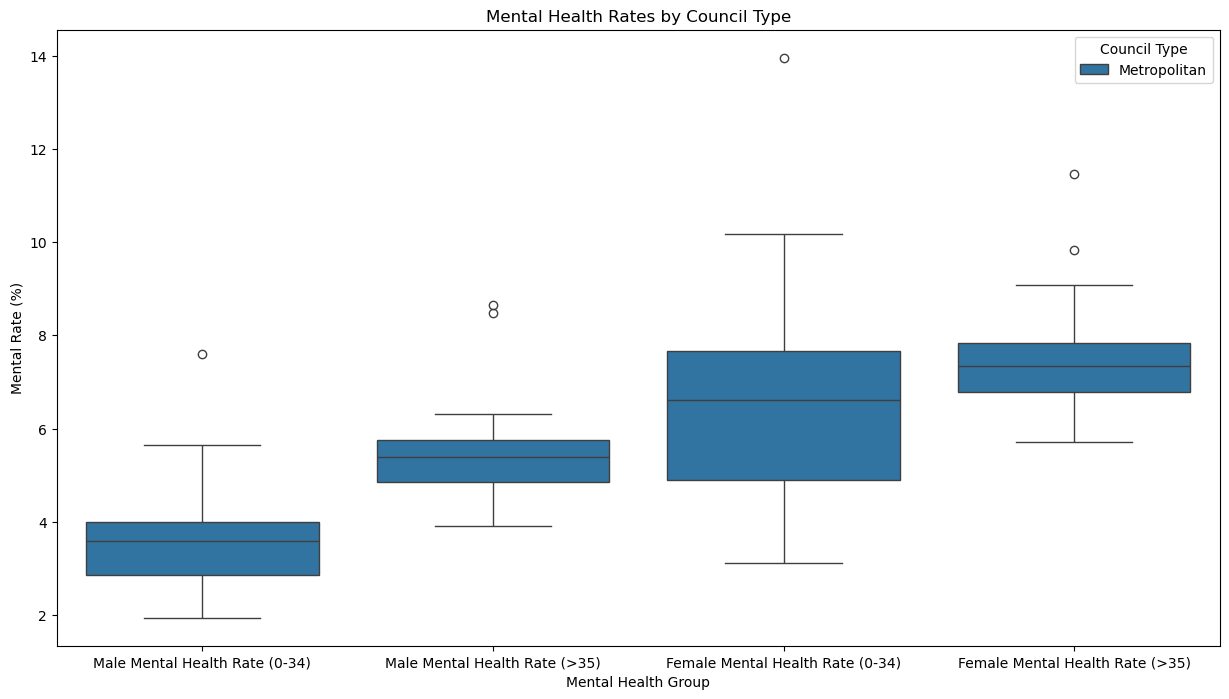

In [24]:
# Create and set the figure size 
fig, ax = plt.subplots(figsize=(15, 8))
# Plot for mental health
sns.boxplot(data=df_mental_health_melted,
            x="Mental Health Group",
            y="Mental Health Rate",
            hue="Council Type",
            ax=ax)

# Customize the plot
ax.set_title('Mental Health Rates by Council Type')
ax.set_ylabel('Mental Rate (%)')

Text(0, 0.5, 'Crime Rate (%)')

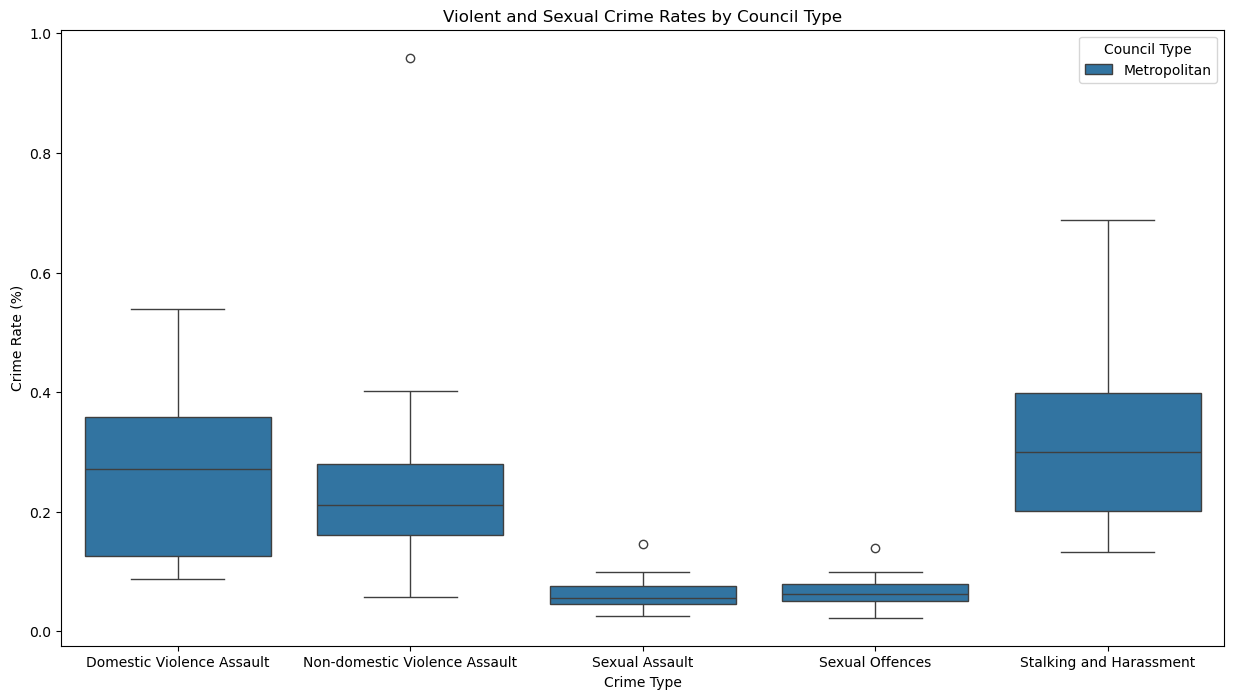

In [25]:
# Create and set the figure size 
fig, ax = plt.subplots(figsize=(15, 8))
# Plot for mental health
sns.boxplot(data=df_violent_crime_melted,
            x="Crime Type",
            y="Crime Rate",
            hue="Council Type",
            ax=ax)

# Customize the plot
ax.set_title('Violent and Sexual Crime Rates by Council Type')
ax.set_ylabel('Crime Rate (%)')

Text(0.5, 1.0, 'Socio-Demographic Indexes by Council Type')

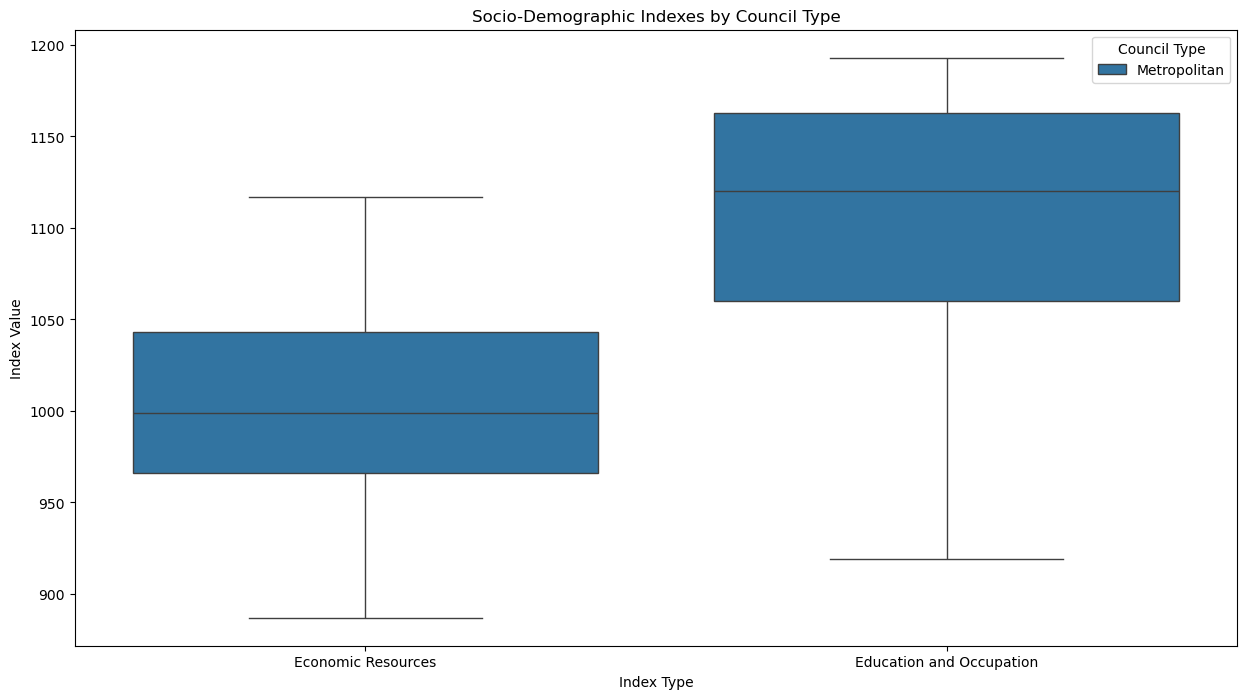

In [26]:
# Create and set the figure size 
fig, ax = plt.subplots(figsize=(15, 8))
# Plot for mental health
sns.boxplot(data=df_indexes_melted,
            x="Index Type",
            y="Index Value",
            hue="Council Type",
            ax=ax)

# Customize the plot
ax.set_title('Socio-Demographic Indexes by Council Type')

#### Barcharts

Text(0, 0.5, 'Mental Health Rate (%)')

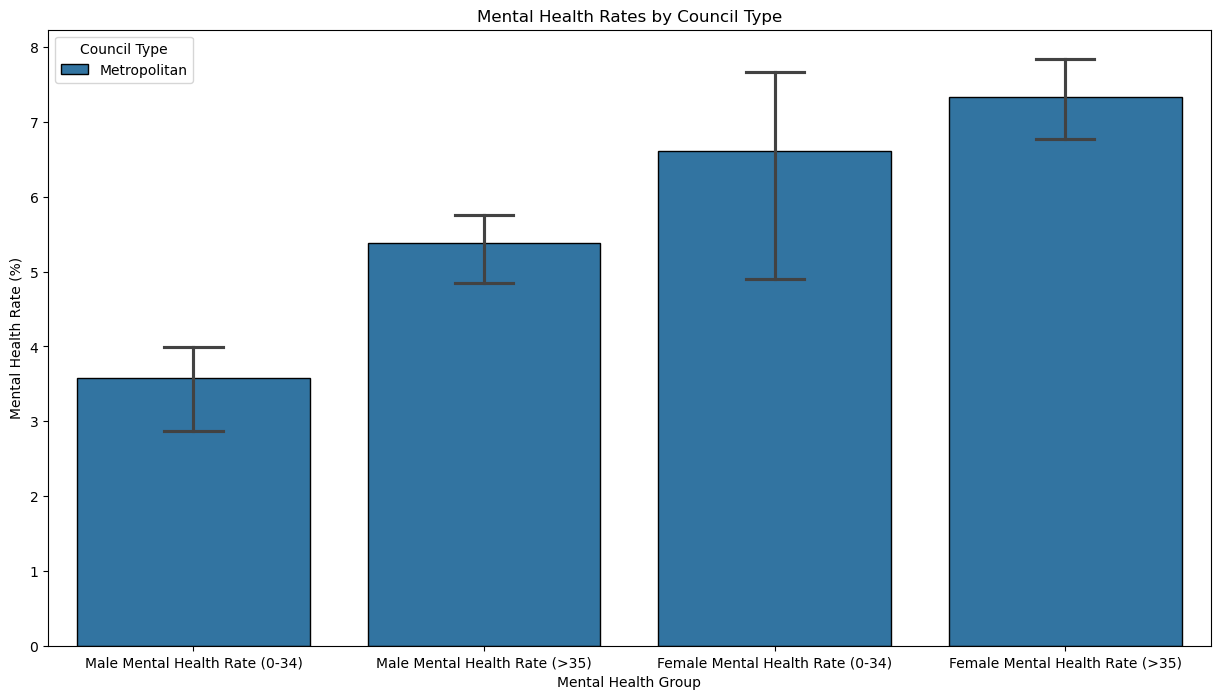

In [27]:
# Create and set the figure size 
fig, ax = plt.subplots(figsize=(15, 8))
# Plot for mental health for median
sns.barplot(data=df_mental_health_melted,
            x="Mental Health Group",
            y="Mental Health Rate",
            hue="Council Type",
            estimator=np.median,
            errorbar=("pi", 50),
            edgecolor="black",
            capsize=0.2,
            ax=ax)

# Customize the plot
ax.set_title('Mental Health Rates by Council Type')
ax.set_ylabel('Mental Health Rate (%)')

Text(0, 0.5, 'Crime Rate (%)')

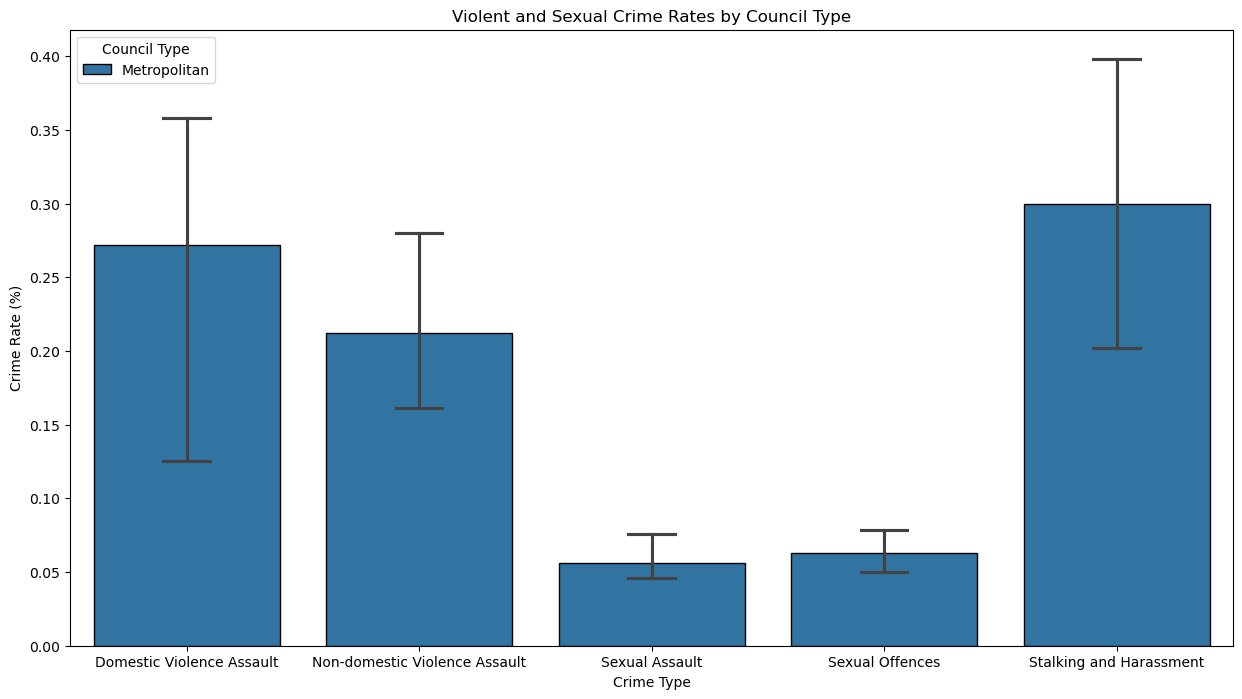

In [28]:
# Create and set the figure size 
fig, ax = plt.subplots(figsize=(15, 8))
# Plot for violent crime for median
sns.barplot(data=df_violent_crime_melted,
            x="Crime Type",
            y="Crime Rate",
            hue="Council Type",
            estimator=np.median,
            errorbar=("pi", 50),
            edgecolor="black",
            capsize=0.2,
            ax=ax)


# Customize the plot
ax.set_title('Violent and Sexual Crime Rates by Council Type')
ax.set_ylabel('Crime Rate (%)')

Text(0.5, 1.0, 'Socio-Demographic Indexes by Council Type')

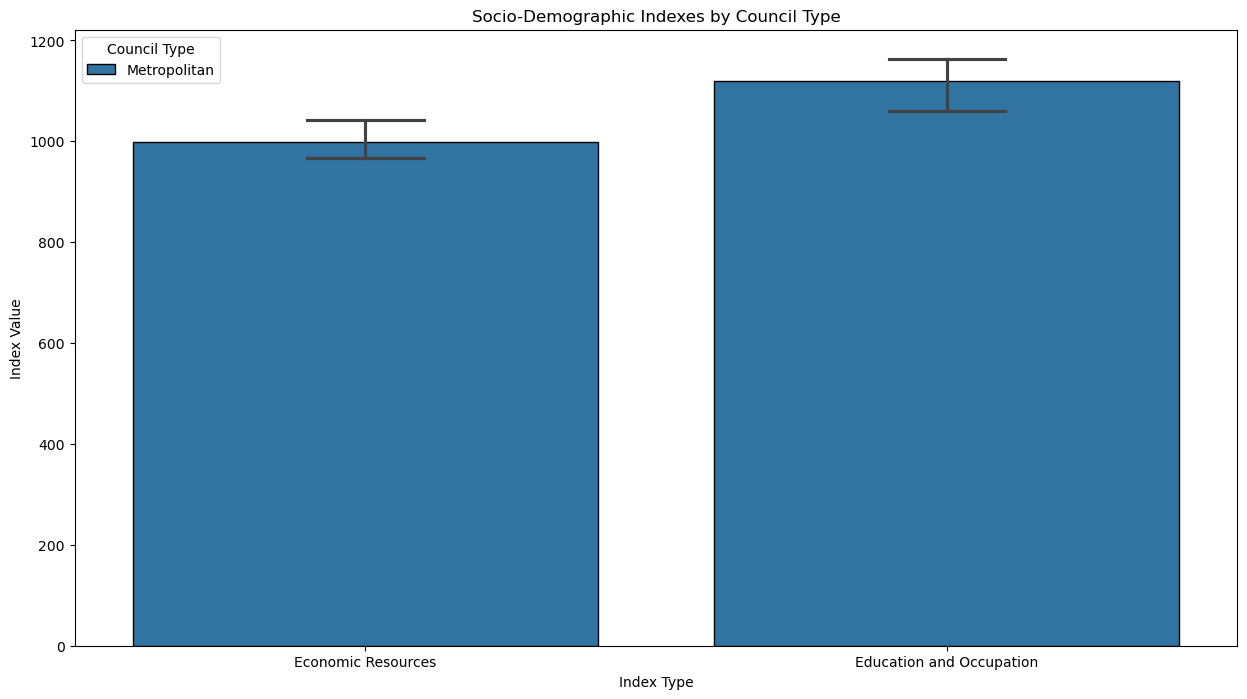

In [29]:
# Create and set the figure size 
fig, ax = plt.subplots(figsize=(15, 8))
# Plot for socio-demographic indexes for medians
sns.barplot(data=df_indexes_melted,
            x="Index Type",
            y="Index Value",
            hue="Council Type",
            estimator=np.median,
            errorbar=("pi", 50),
            edgecolor="black",
            capsize=0.2,
            ax=ax)

# Customize the plot
ax.set_title('Socio-Demographic Indexes by Council Type')

#### Scatterplots

In [30]:
# Rename the columns for better readability
df_crime_health_seifa_council = df_crime_health_seifa_council.rename(columns={
    'Index of Relative Socio-economic Disadvantage Score': 'Socio-economic Disadvantage',
    'Index of Relative Socio-economic Advantage and Disadvantage Score': 'Socio-economic Advantage/Disadvantage',
    'Index of Economic Resources Score': 'Economic Resources',
    'Index of Education and Occupation Score': 'Education and Occupation',
    'M_Mental_health_rate_0_34': 'Male Mental Health Rate (0-34)',
    'M_Mental_health_rate_35_85_over': 'Male Mental Health Rate (>35)',
    'F_Mental_health_rate_0_34': 'Female Mental Health Rate (0-34)',
    'F_Mental_health_rate_35_85_over': 'Female Mental Health Rate (>35)',
    'Domestic violence related assault': 'Domestic Violence Assault',
    'Non-domestic violence related assault': 'Non-domestic Violence Assault',
    'Assault Police': 'Assault on Police',
    'Sexual assault': 'Sexual Assault',
    'Sexual touching, sexual act and other sexual offences': 'Sexual Offences',
    'Intimidation, stalking and harassment': 'Stalking and Harassment'})
df_crime_health_seifa_council.head(10)

,Socio-economic Disadvantage,Socio-economic Advantage/Disadvantage,Economic Resources,Education and Occupation,Male Mental Health Rate (0-34),Male Mental Health Rate (>35),Female Mental Health Rate (0-34),Female Mental Health Rate (>35),Domestic Violence Assault,Non-domestic Violence Assault,Assault on Police,Sexual Assault,Sexual Offences,Stalking and Harassment,OLG Group,Council Type
LGA_NAME_2021,,,,,,,,,,,,,,,,
Bayside (NSW),1004,1044,966,1051,0.028677,0.055065,0.050046,0.078394,0.003579,0.002226,0.000257,0.000491,0.000502,0.003859,3,Metropolitan
Blacktown,987,1006,1020,993,0.037010,0.057632,0.058605,0.086142,0.005391,0.004017,0.000315,0.000980,0.000996,0.006780,3,Metropolitan
Burwood,977,1050,926,1082,0.028264,0.050542,0.049024,0.061361,0.002288,0.002636,0.000075,0.000348,0.000746,0.002884,2,Metropolitan
Canada Bay,1067,1116,1021,1123,0.032258,0.050195,0.056729,0.068959,0.001469,0.001413,0.000112,0.000606,0.000426,0.002018,3,Metropolitan
Canterbury-Bankstown,917,966,949,996,0.025515,0.053910,0.042591,0.078413,0.003676,0.002121,0.000213,0.000534,0.000628,0.004526,3,Metropolitan
Cumberland,904,961,931,995,0.019417,0.048478,0.031110,0.073811,0.003742,0.002829,0.000229,0.000561,0.000607,0.004226,3,Metropolitan
Fairfield,814,885,937,919,0.023048,0.056489,0.031785,0.075222,0.003828,0.002346,0.000259,0.000422,0.000758,0.005171,3,Metropolitan
Georges River,1011,1048,999,1060,0.026757,0.048115,0.046224,0.067338,0.002837,0.002042,0.000177,0.000401,0.000598,0.002995,3,Metropolitan
Hunters Hill,1101,1156,1088,1163,0.044626,0.052105,0.068557,0.068241,0.001254,0.001328,0.000000,0.000811,0.000811,0.001549,2,Metropolitan



Analyzing correlation for Socio-economic Disadvantage and Socio-economic Advantage/Disadvantage


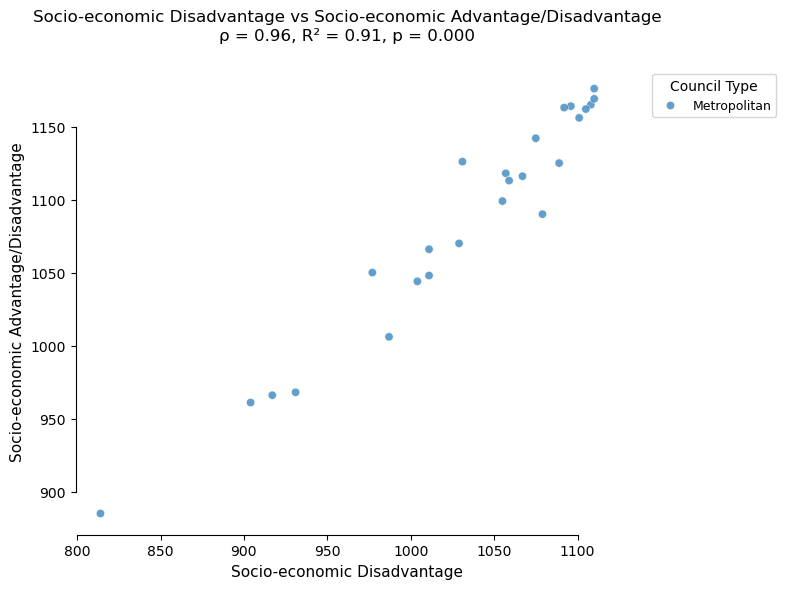

  - Socio-economic Disadvantage vs Socio-economic Advantage/Disadvantage: Correlation is significant (p=0.0000)

Analyzing correlation for Socio-economic Disadvantage and Economic Resources


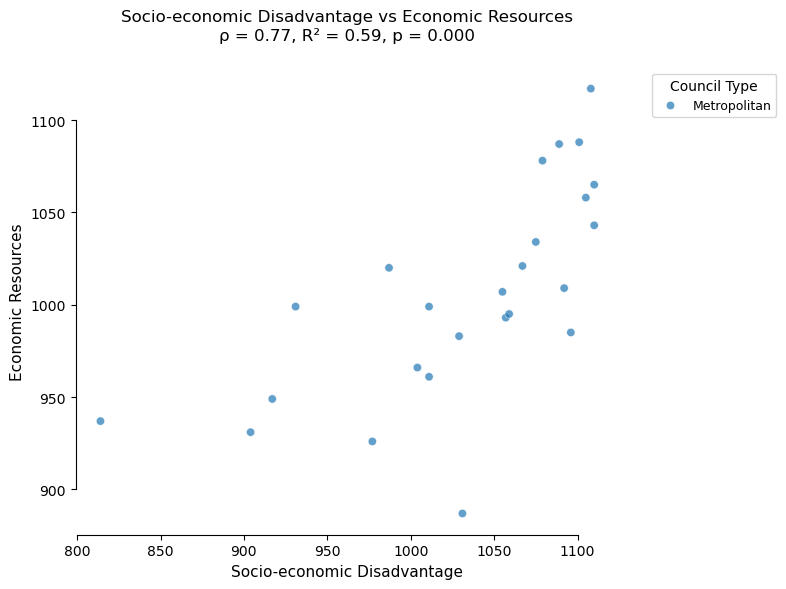

  - Socio-economic Disadvantage vs Economic Resources: Correlation is significant (p=0.0000)

Analyzing correlation for Socio-economic Disadvantage and Education and Occupation


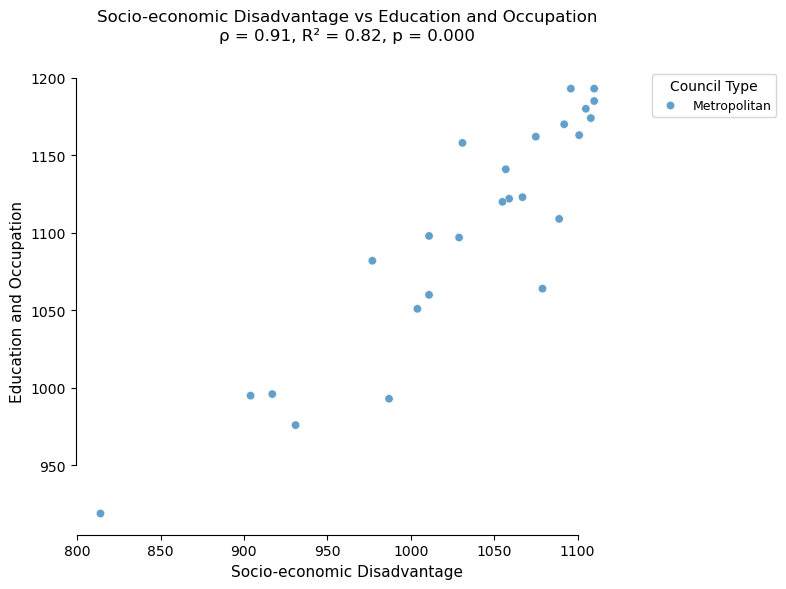

  - Socio-economic Disadvantage vs Education and Occupation: Correlation is significant (p=0.0000)

Analyzing correlation for Socio-economic Disadvantage and Male Mental Health Rate (0-34)


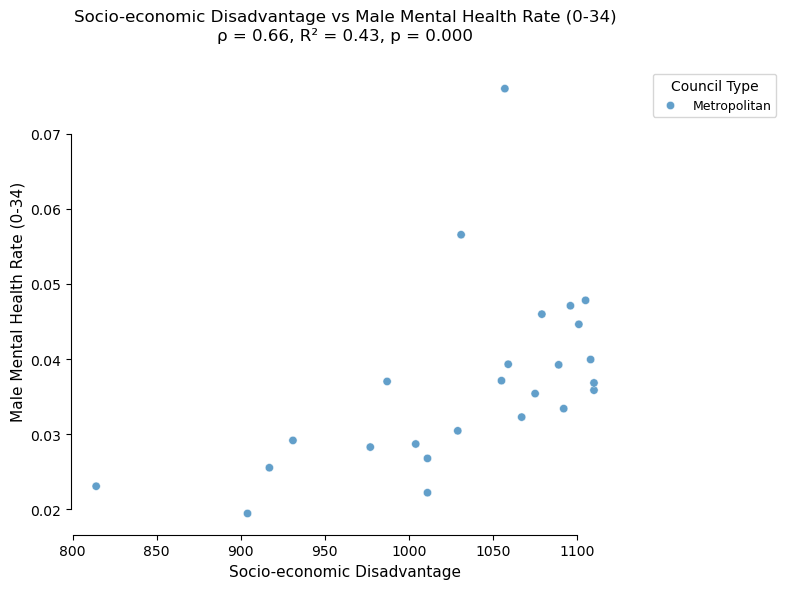

  - Socio-economic Disadvantage vs Male Mental Health Rate (0-34): Correlation is significant (p=0.0004)

Analyzing correlation for Socio-economic Disadvantage and Male Mental Health Rate (>35)


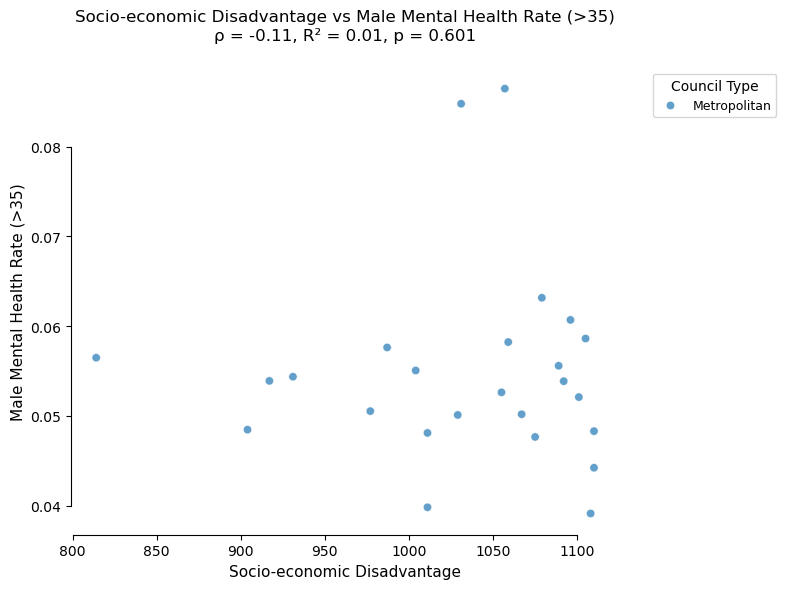

  - Socio-economic Disadvantage vs Male Mental Health Rate (>35): Correlation is not significant (p=0.6005)

Analyzing correlation for Socio-economic Disadvantage and Female Mental Health Rate (0-34)


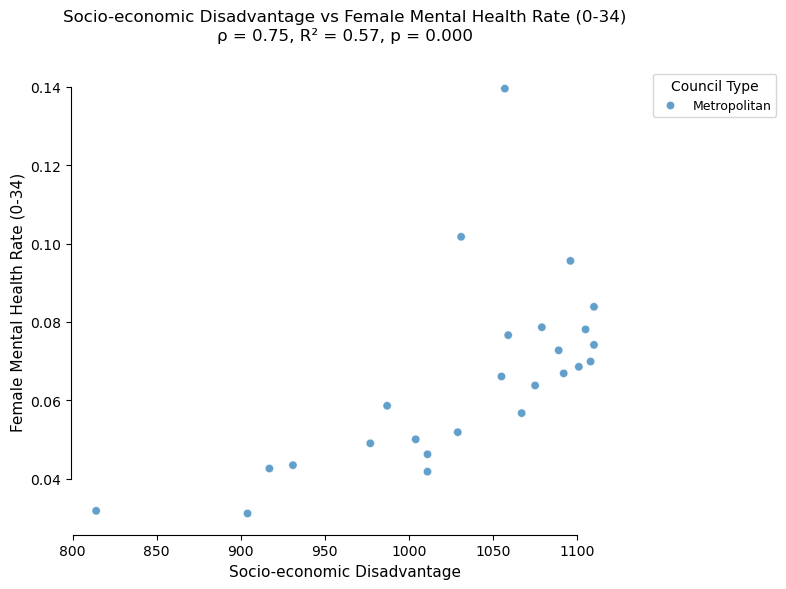

  - Socio-economic Disadvantage vs Female Mental Health Rate (0-34): Correlation is significant (p=0.0000)

Analyzing correlation for Socio-economic Disadvantage and Female Mental Health Rate (>35)


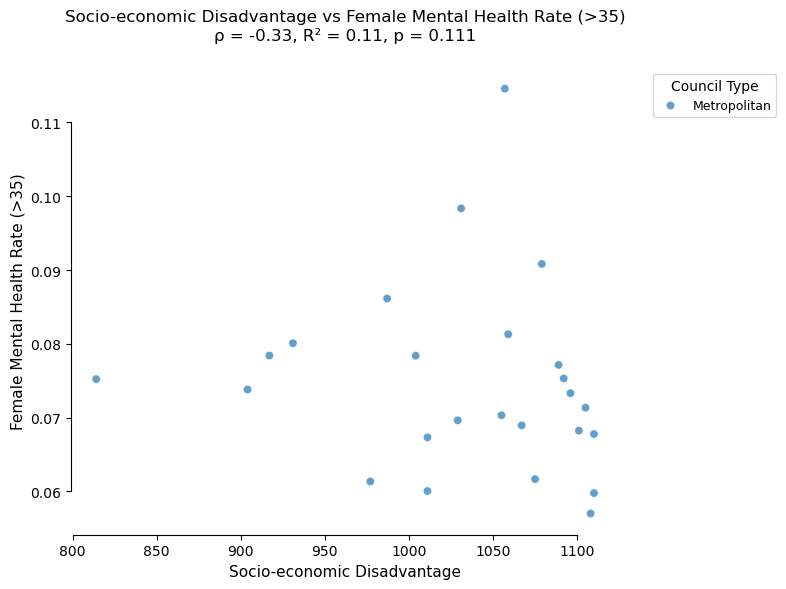

  - Socio-economic Disadvantage vs Female Mental Health Rate (>35): Correlation is not significant (p=0.1114)

Analyzing correlation for Socio-economic Disadvantage and Domestic Violence Assault


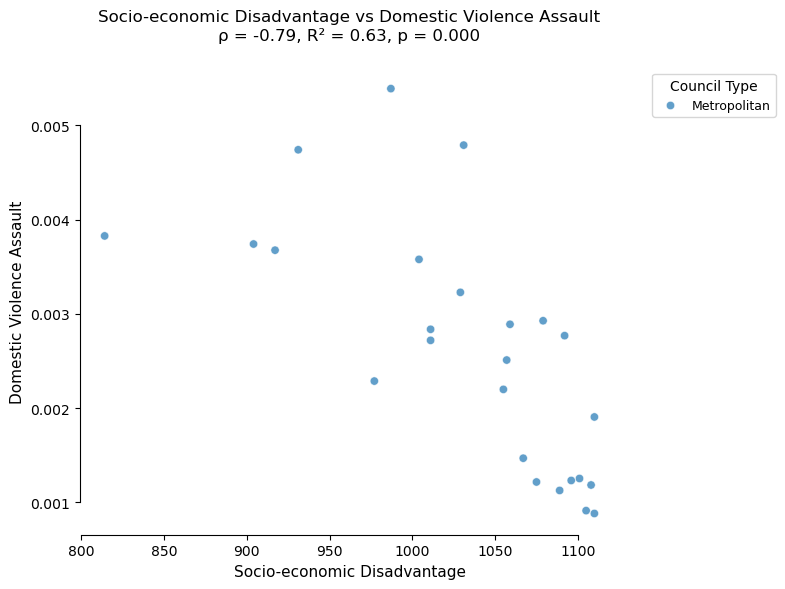

  - Socio-economic Disadvantage vs Domestic Violence Assault: Correlation is significant (p=0.0000)

Analyzing correlation for Socio-economic Disadvantage and Non-domestic Violence Assault


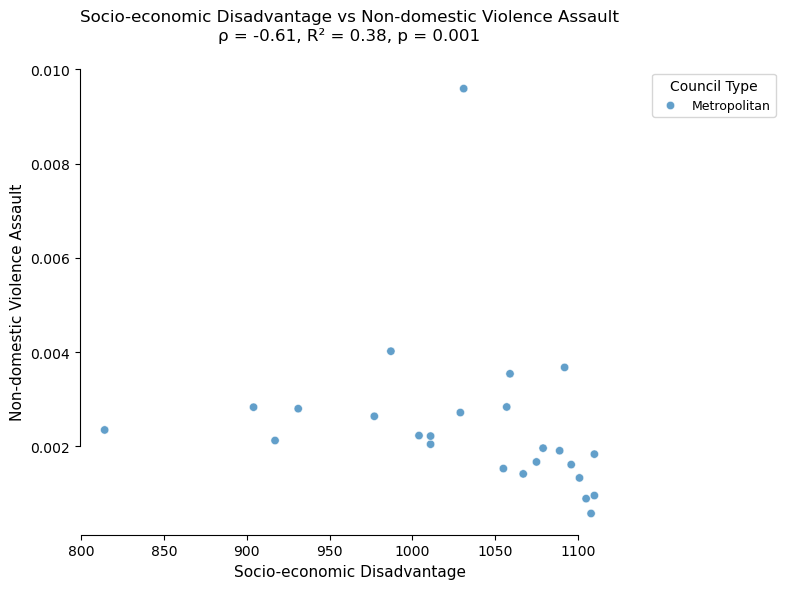

  - Socio-economic Disadvantage vs Non-domestic Violence Assault: Correlation is significant (p=0.0011)

Analyzing correlation for Socio-economic Disadvantage and Assault on Police


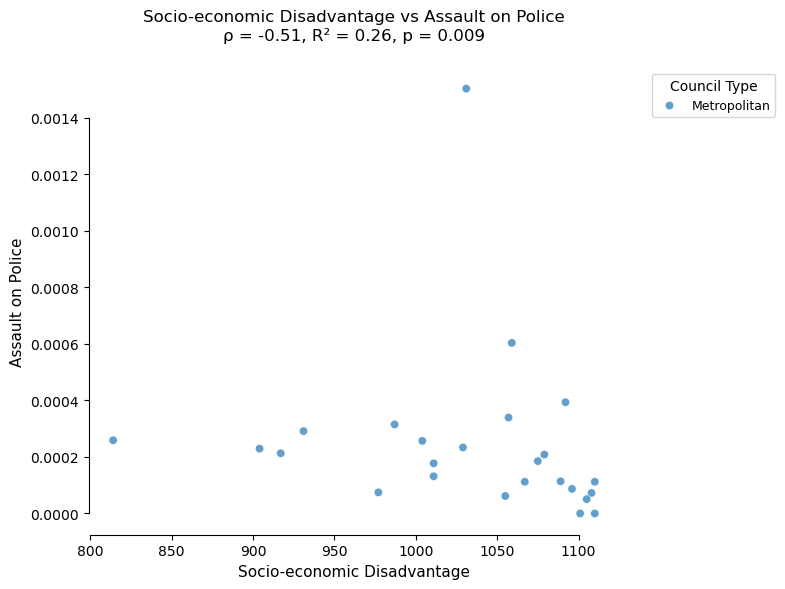

  - Socio-economic Disadvantage vs Assault on Police: Correlation is significant (p=0.0091)

Analyzing correlation for Socio-economic Disadvantage and Sexual Assault


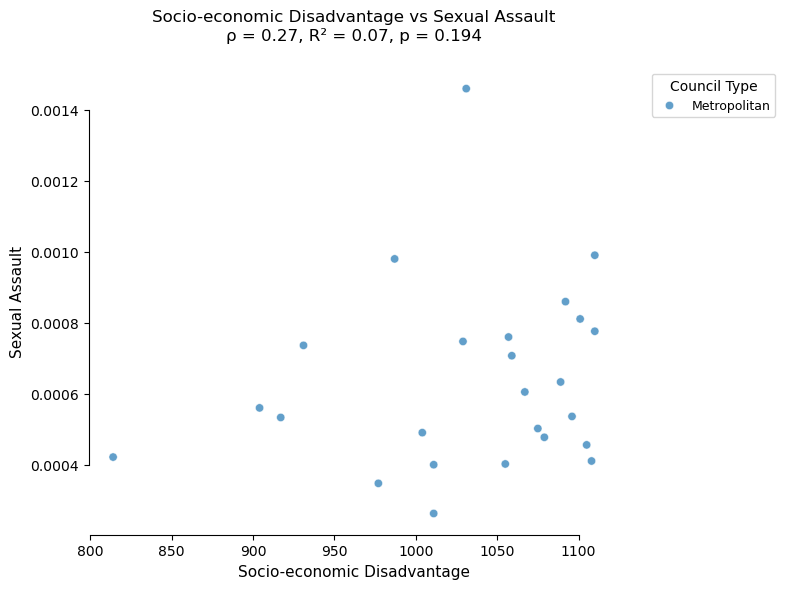

  - Socio-economic Disadvantage vs Sexual Assault: Correlation is not significant (p=0.1943)

Analyzing correlation for Socio-economic Disadvantage and Sexual Offences


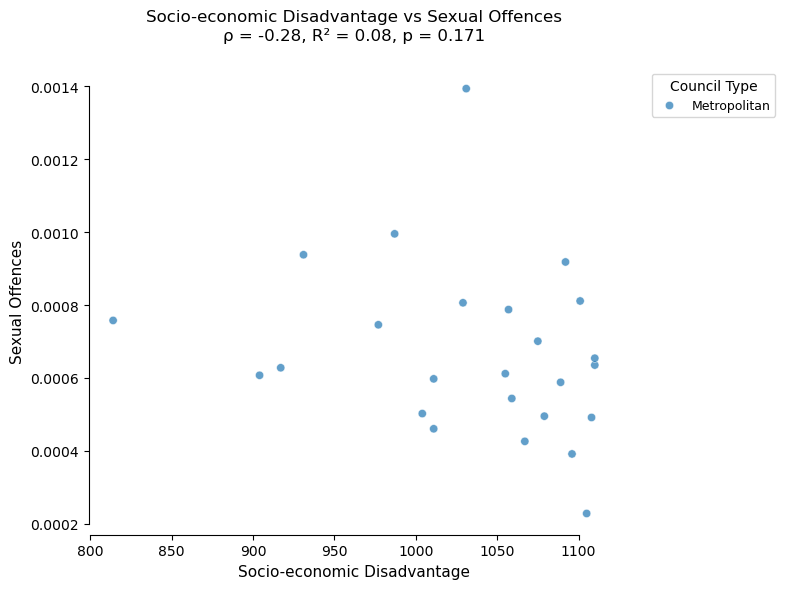

  - Socio-economic Disadvantage vs Sexual Offences: Correlation is not significant (p=0.1708)

Analyzing correlation for Socio-economic Disadvantage and Stalking and Harassment


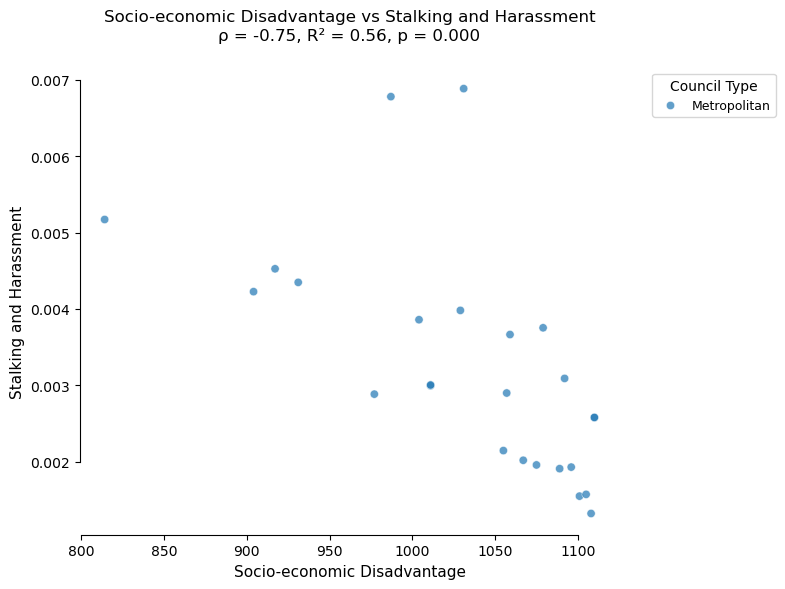

  - Socio-economic Disadvantage vs Stalking and Harassment: Correlation is significant (p=0.0000)

Analyzing correlation for Socio-economic Advantage/Disadvantage and Economic Resources


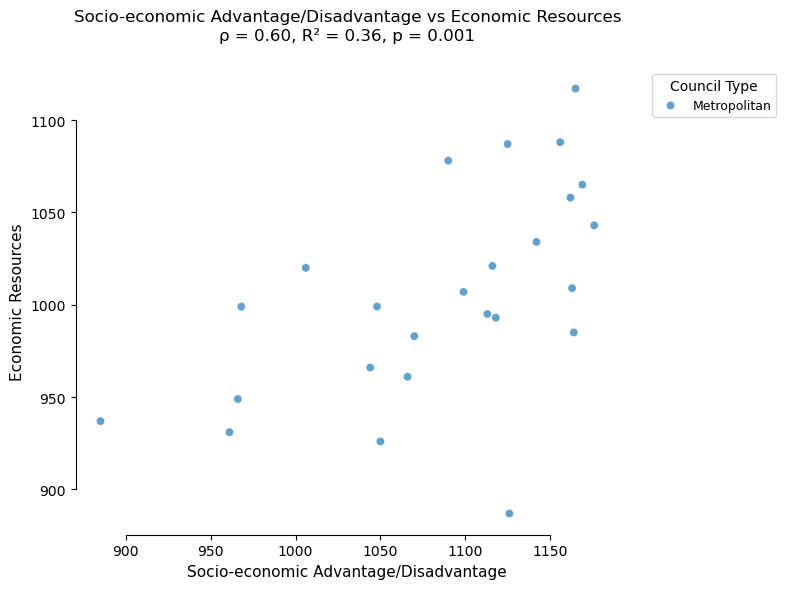

  - Socio-economic Advantage/Disadvantage vs Economic Resources: Correlation is significant (p=0.0015)

Analyzing correlation for Socio-economic Advantage/Disadvantage and Education and Occupation


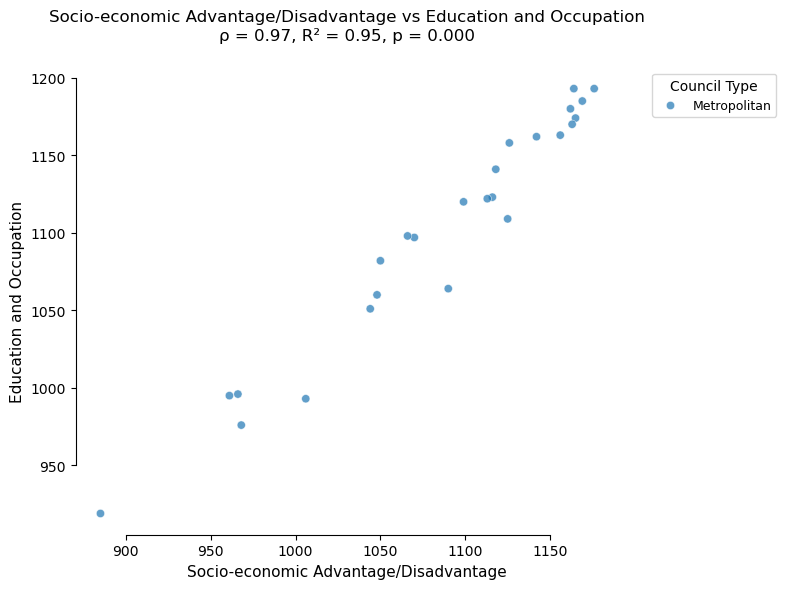

  - Socio-economic Advantage/Disadvantage vs Education and Occupation: Correlation is significant (p=0.0000)

Analyzing correlation for Socio-economic Advantage/Disadvantage and Male Mental Health Rate (0-34)


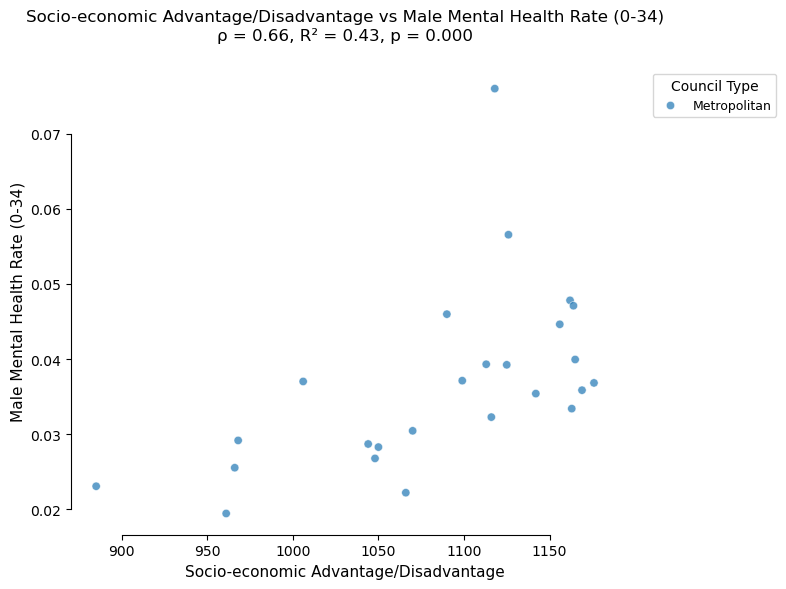

  - Socio-economic Advantage/Disadvantage vs Male Mental Health Rate (0-34): Correlation is significant (p=0.0004)

Analyzing correlation for Socio-economic Advantage/Disadvantage and Male Mental Health Rate (>35)


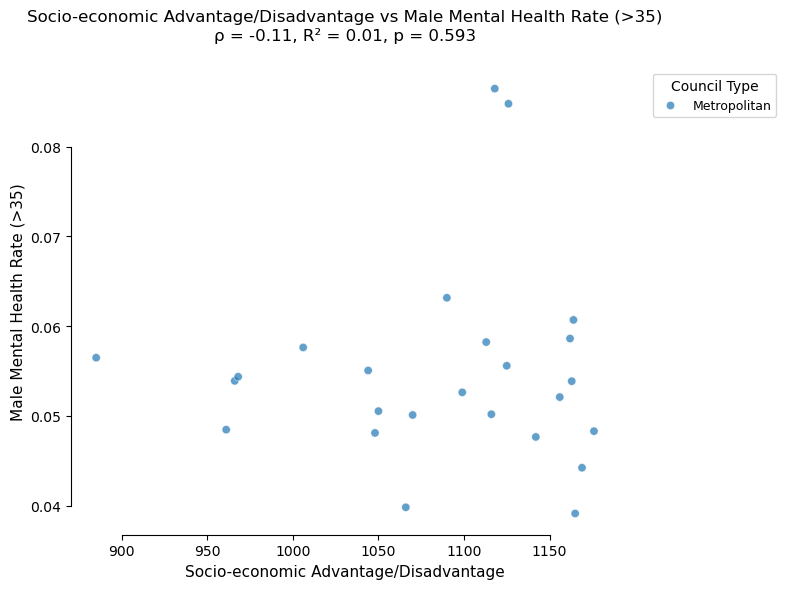

  - Socio-economic Advantage/Disadvantage vs Male Mental Health Rate (>35): Correlation is not significant (p=0.5930)

Analyzing correlation for Socio-economic Advantage/Disadvantage and Female Mental Health Rate (0-34)


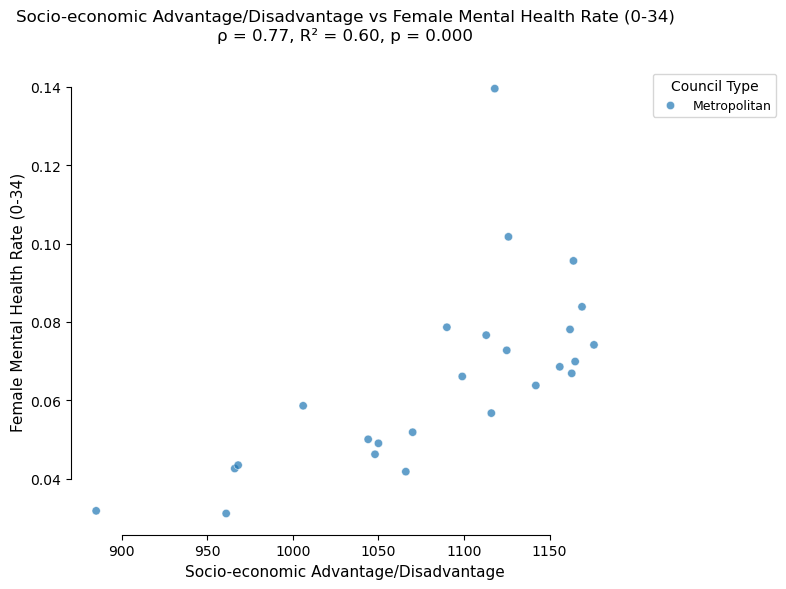

  - Socio-economic Advantage/Disadvantage vs Female Mental Health Rate (0-34): Correlation is significant (p=0.0000)

Analyzing correlation for Socio-economic Advantage/Disadvantage and Female Mental Health Rate (>35)


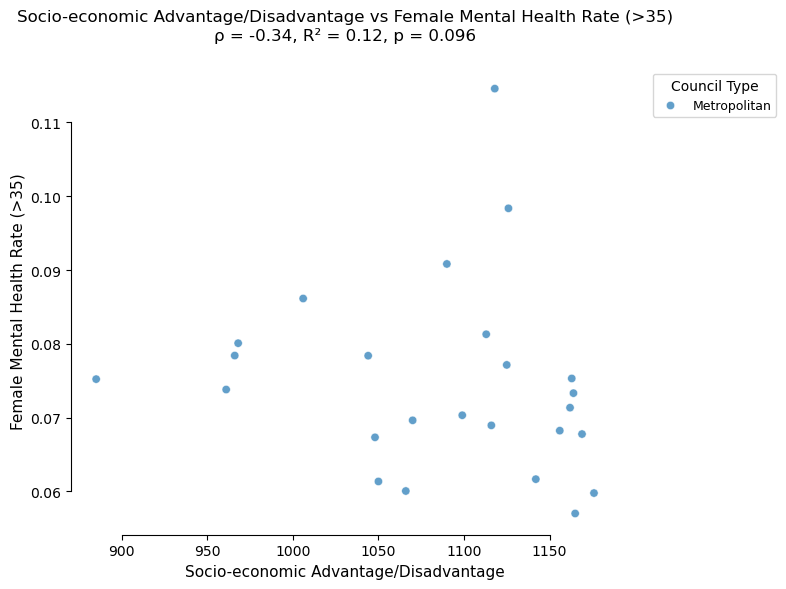

  - Socio-economic Advantage/Disadvantage vs Female Mental Health Rate (>35): Correlation is not significant (p=0.0963)

Analyzing correlation for Socio-economic Advantage/Disadvantage and Domestic Violence Assault


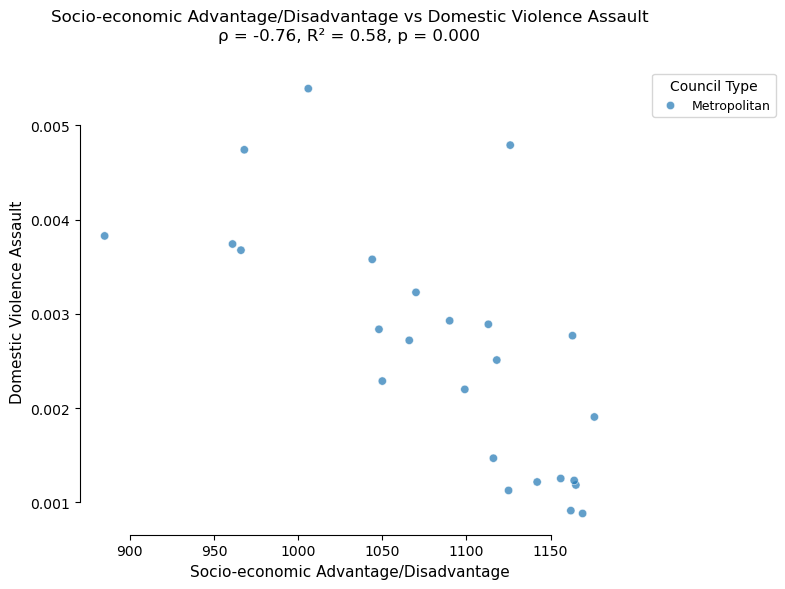

  - Socio-economic Advantage/Disadvantage vs Domestic Violence Assault: Correlation is significant (p=0.0000)

Analyzing correlation for Socio-economic Advantage/Disadvantage and Non-domestic Violence Assault


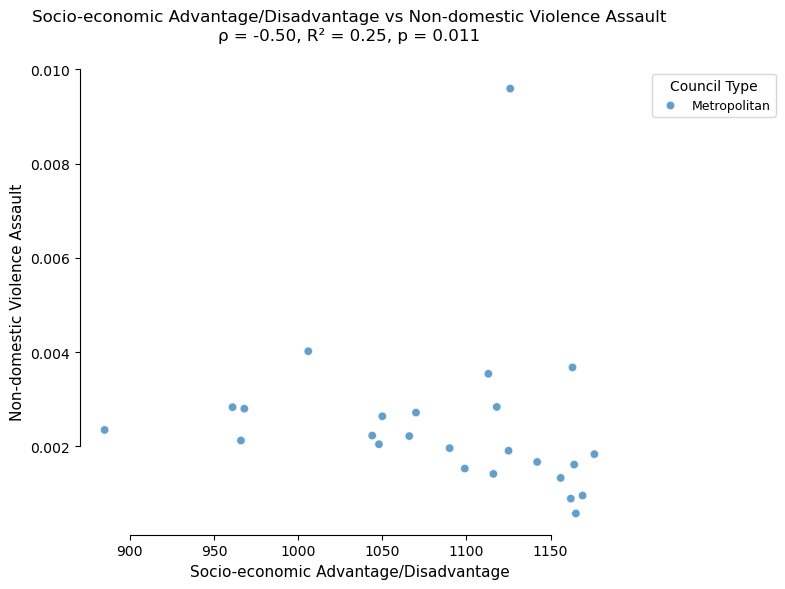

  - Socio-economic Advantage/Disadvantage vs Non-domestic Violence Assault: Correlation is significant (p=0.0106)

Analyzing correlation for Socio-economic Advantage/Disadvantage and Assault on Police


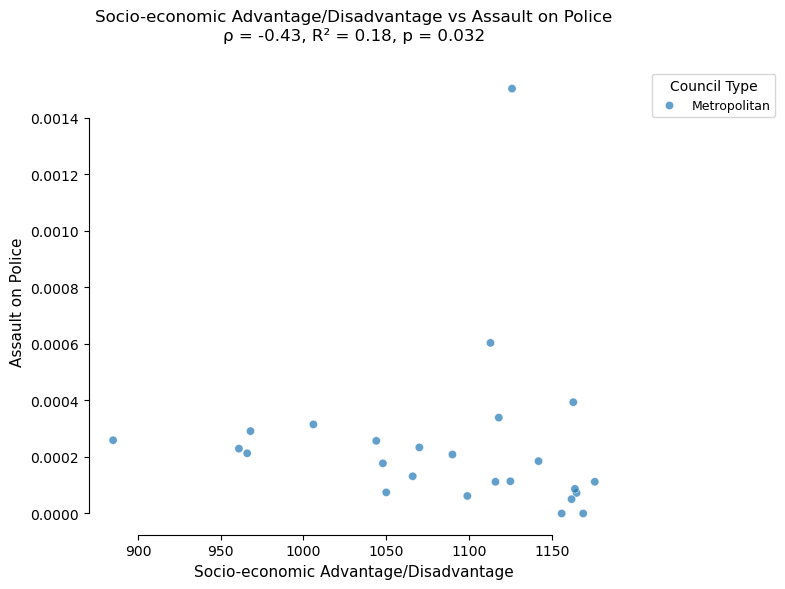

  - Socio-economic Advantage/Disadvantage vs Assault on Police: Correlation is significant (p=0.0321)

Analyzing correlation for Socio-economic Advantage/Disadvantage and Sexual Assault


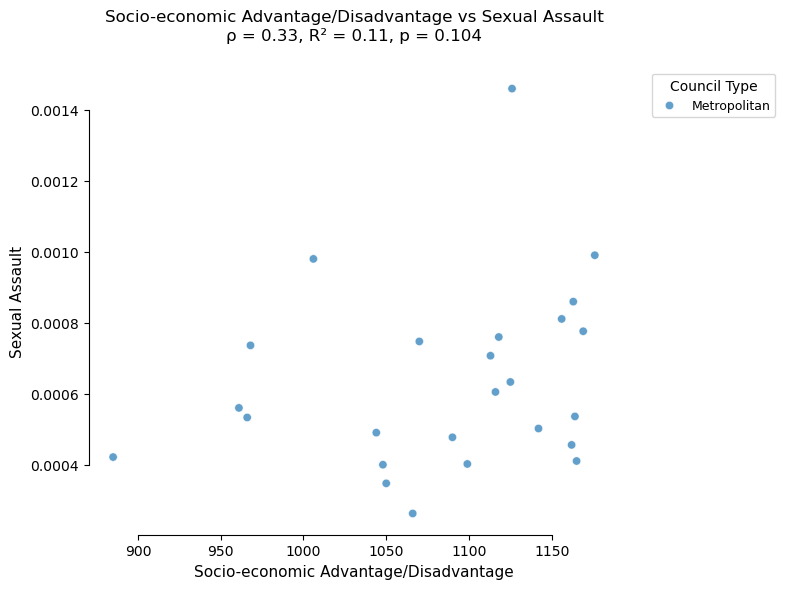

  - Socio-economic Advantage/Disadvantage vs Sexual Assault: Correlation is not significant (p=0.1037)

Analyzing correlation for Socio-economic Advantage/Disadvantage and Sexual Offences


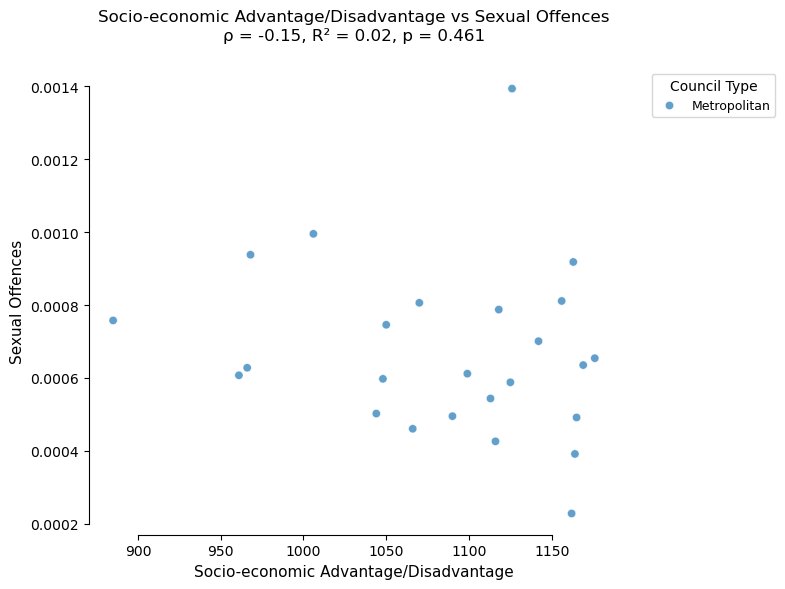

  - Socio-economic Advantage/Disadvantage vs Sexual Offences: Correlation is not significant (p=0.4605)

Analyzing correlation for Socio-economic Advantage/Disadvantage and Stalking and Harassment


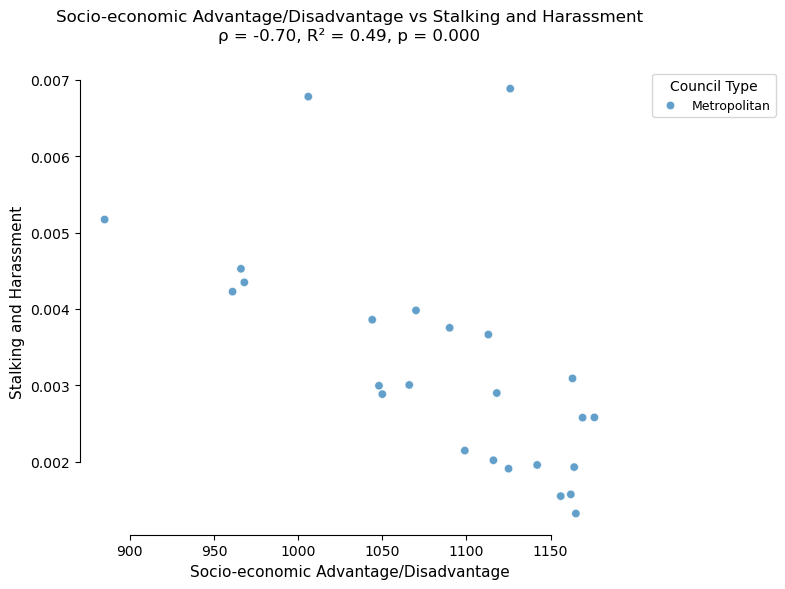

  - Socio-economic Advantage/Disadvantage vs Stalking and Harassment: Correlation is significant (p=0.0001)

Analyzing correlation for Economic Resources and Education and Occupation


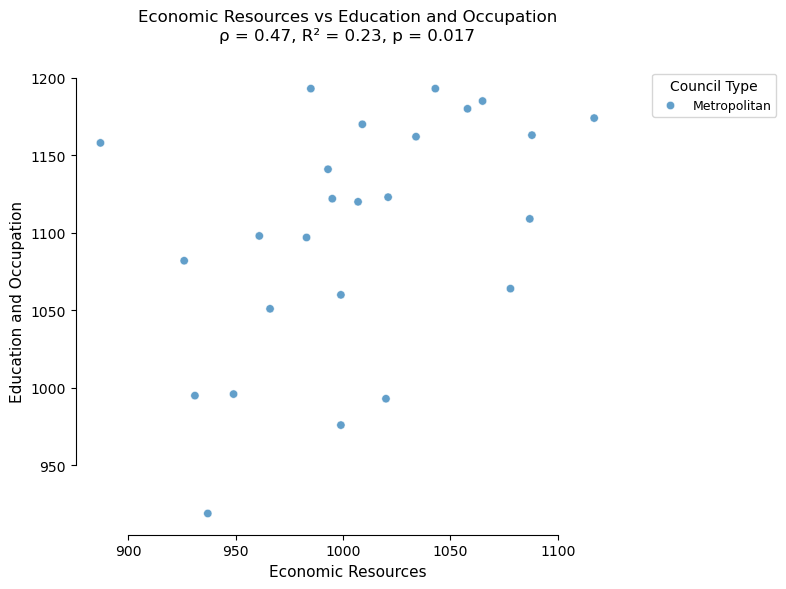

  - Economic Resources vs Education and Occupation: Correlation is significant (p=0.0166)

Analyzing correlation for Economic Resources and Male Mental Health Rate (0-34)


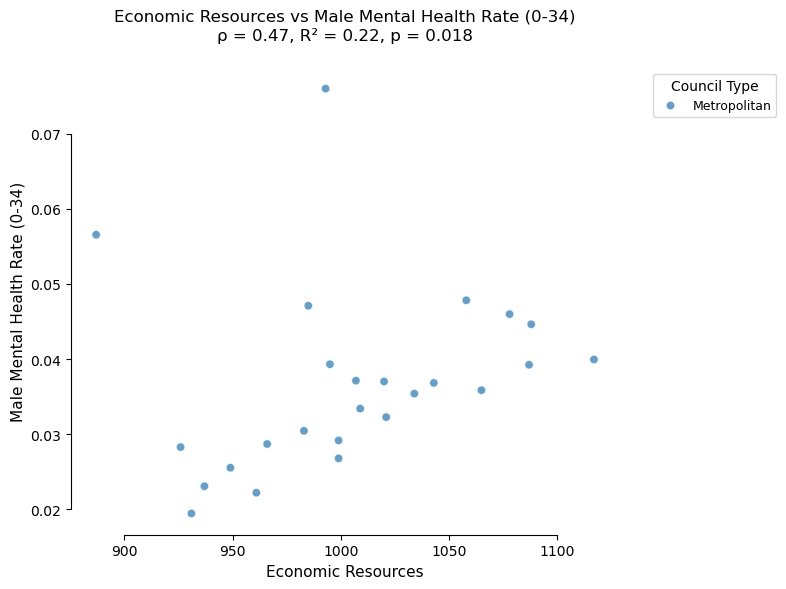

  - Economic Resources vs Male Mental Health Rate (0-34): Correlation is significant (p=0.0180)

Analyzing correlation for Economic Resources and Male Mental Health Rate (>35)


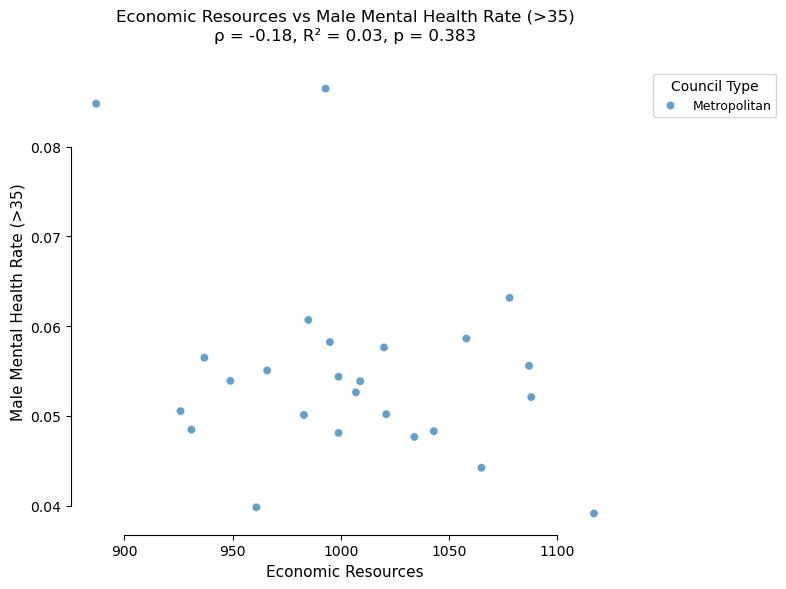

  - Economic Resources vs Male Mental Health Rate (>35): Correlation is not significant (p=0.3830)

Analyzing correlation for Economic Resources and Female Mental Health Rate (0-34)


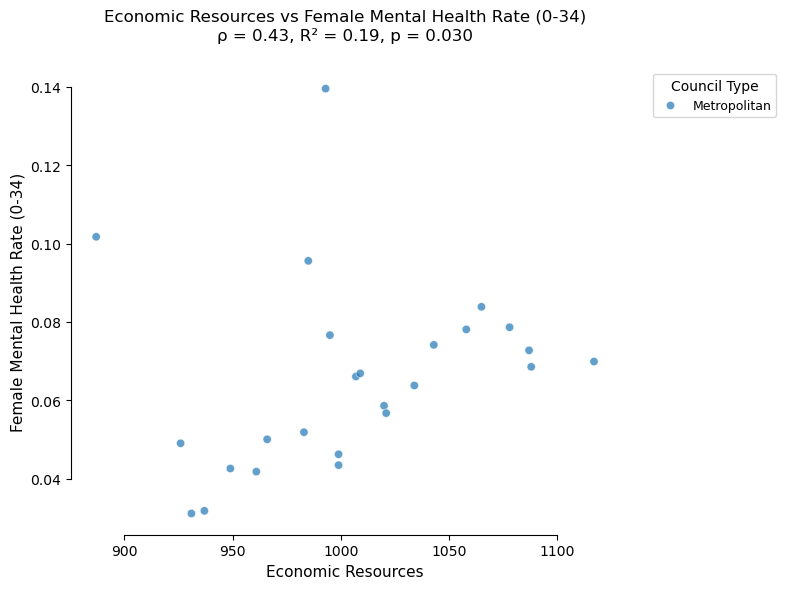

  - Economic Resources vs Female Mental Health Rate (0-34): Correlation is significant (p=0.0301)

Analyzing correlation for Economic Resources and Female Mental Health Rate (>35)


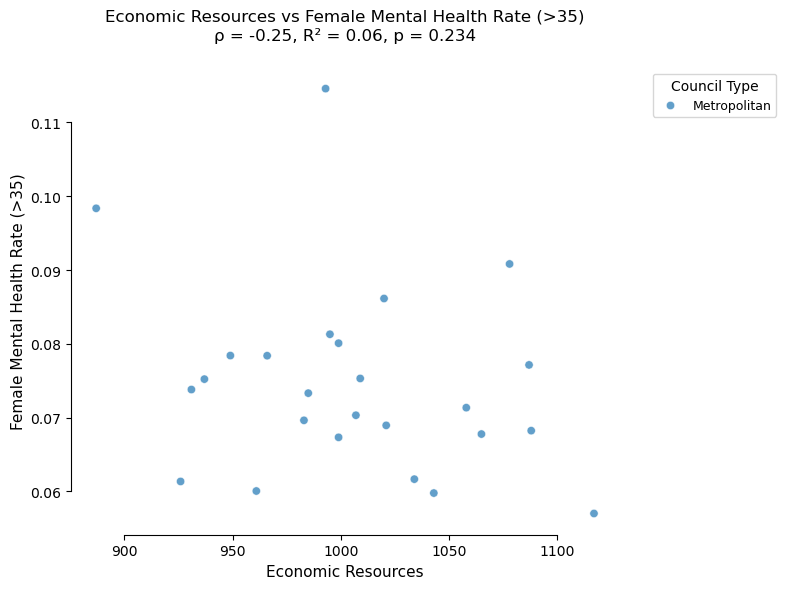

  - Economic Resources vs Female Mental Health Rate (>35): Correlation is not significant (p=0.2340)

Analyzing correlation for Economic Resources and Domestic Violence Assault


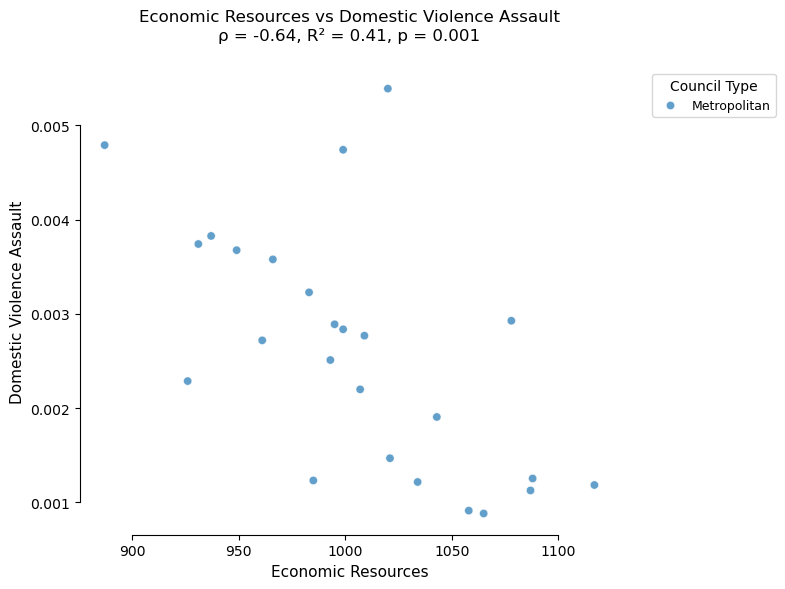

  - Economic Resources vs Domestic Violence Assault: Correlation is significant (p=0.0006)

Analyzing correlation for Economic Resources and Non-domestic Violence Assault


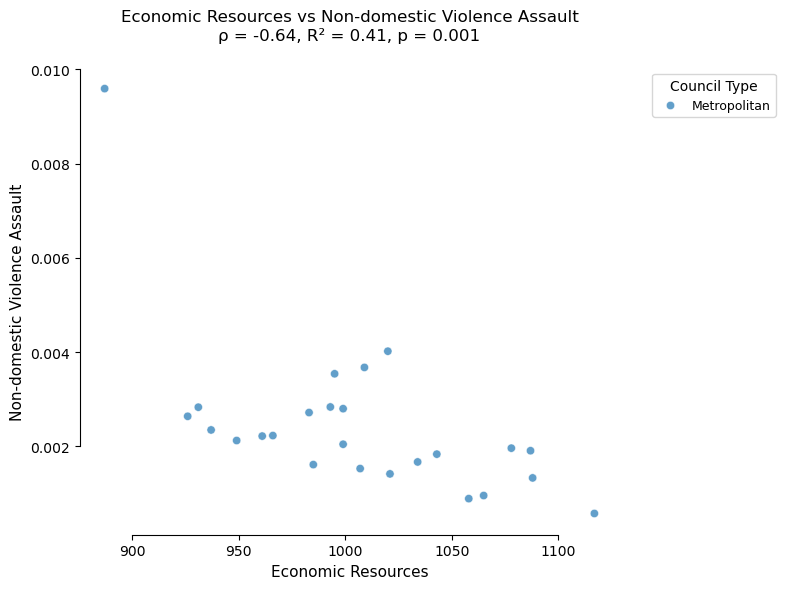

  - Economic Resources vs Non-domestic Violence Assault: Correlation is significant (p=0.0006)

Analyzing correlation for Economic Resources and Assault on Police


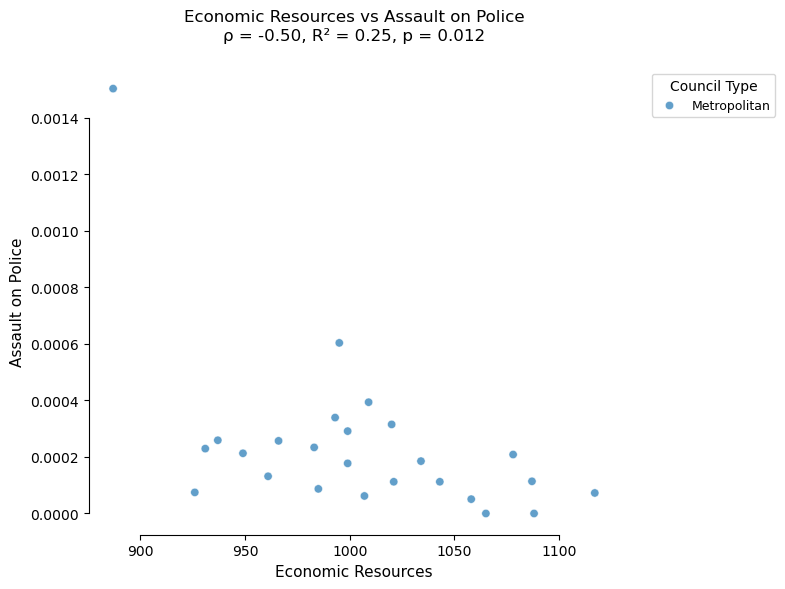

  - Economic Resources vs Assault on Police: Correlation is significant (p=0.0115)

Analyzing correlation for Economic Resources and Sexual Assault


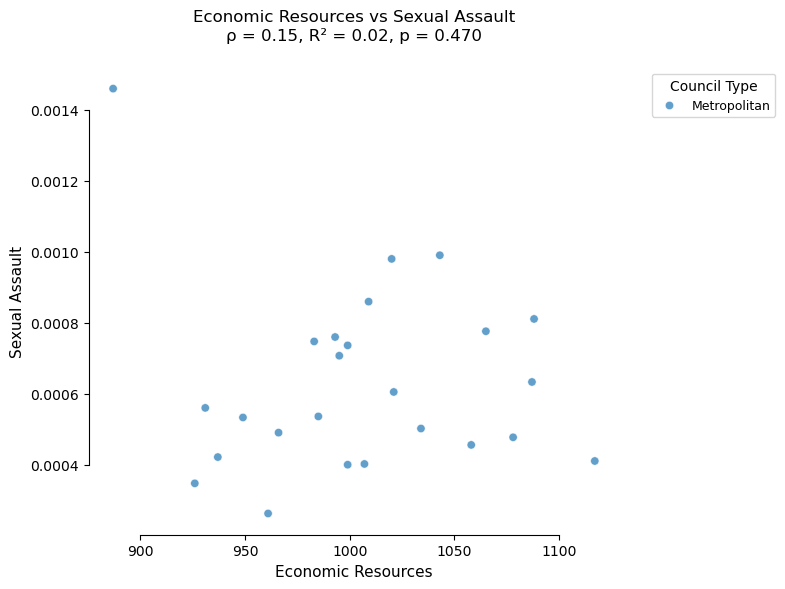

  - Economic Resources vs Sexual Assault: Correlation is not significant (p=0.4695)

Analyzing correlation for Economic Resources and Sexual Offences


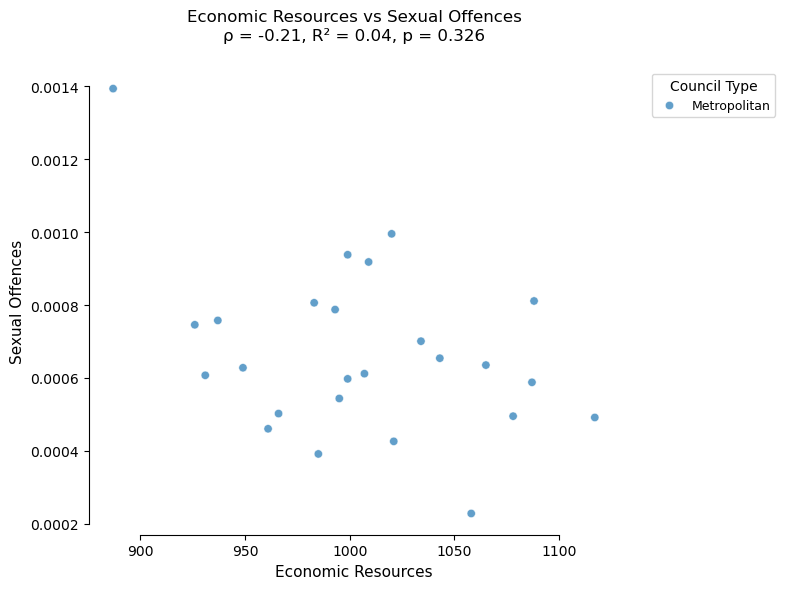

  - Economic Resources vs Sexual Offences: Correlation is not significant (p=0.3255)

Analyzing correlation for Economic Resources and Stalking and Harassment


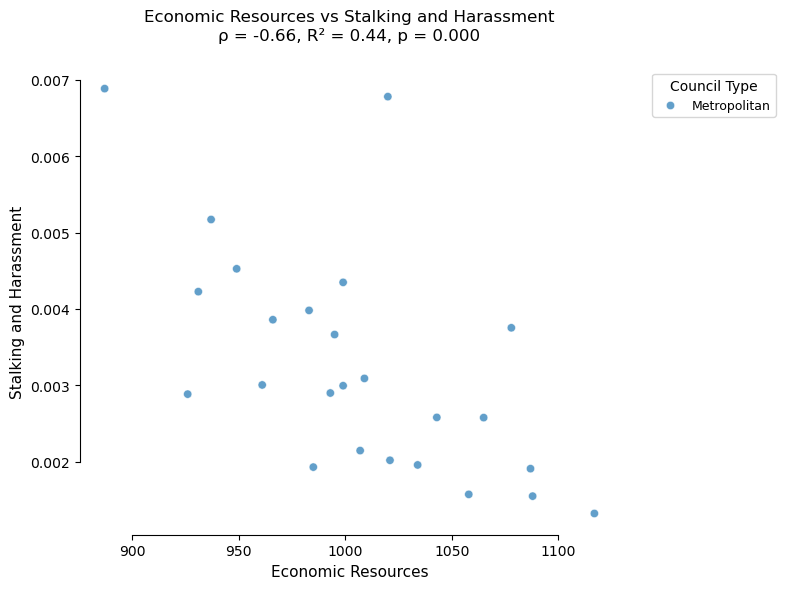

  - Economic Resources vs Stalking and Harassment: Correlation is significant (p=0.0003)

Analyzing correlation for Education and Occupation and Male Mental Health Rate (0-34)


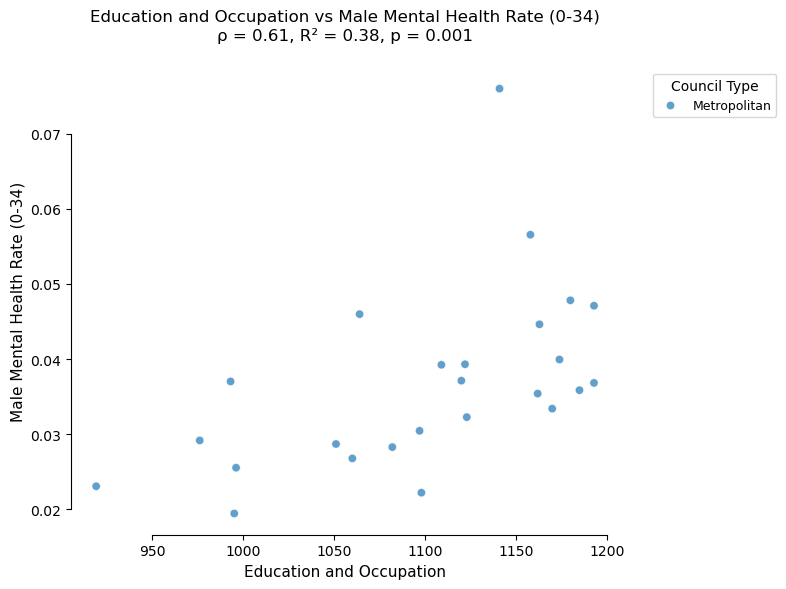

  - Education and Occupation vs Male Mental Health Rate (0-34): Correlation is significant (p=0.0011)

Analyzing correlation for Education and Occupation and Male Mental Health Rate (>35)


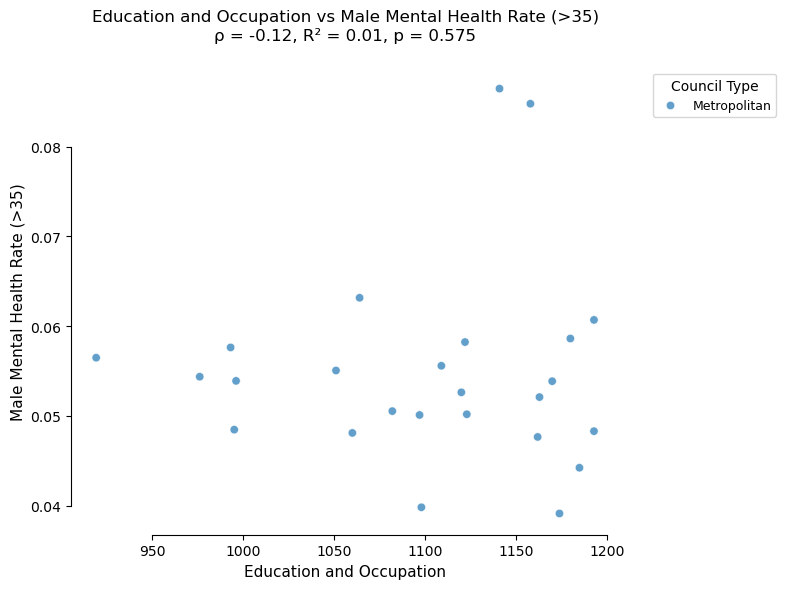

  - Education and Occupation vs Male Mental Health Rate (>35): Correlation is not significant (p=0.5752)

Analyzing correlation for Education and Occupation and Female Mental Health Rate (0-34)


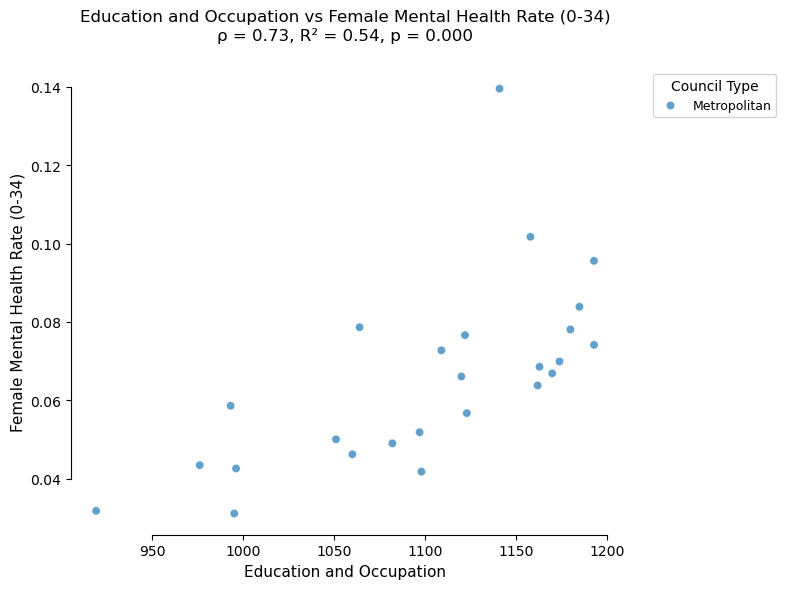

  - Education and Occupation vs Female Mental Health Rate (0-34): Correlation is significant (p=0.0000)

Analyzing correlation for Education and Occupation and Female Mental Health Rate (>35)


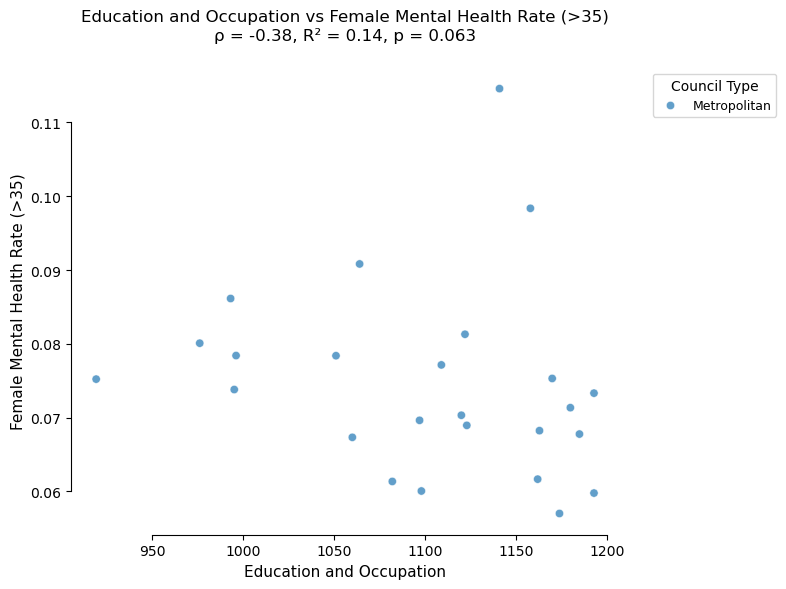

  - Education and Occupation vs Female Mental Health Rate (>35): Correlation is not significant (p=0.0629)

Analyzing correlation for Education and Occupation and Domestic Violence Assault


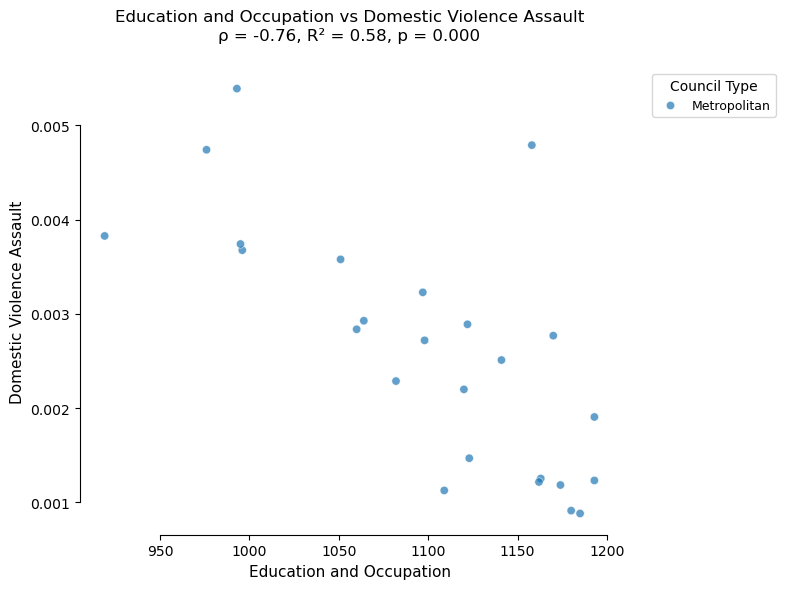

  - Education and Occupation vs Domestic Violence Assault: Correlation is significant (p=0.0000)

Analyzing correlation for Education and Occupation and Non-domestic Violence Assault


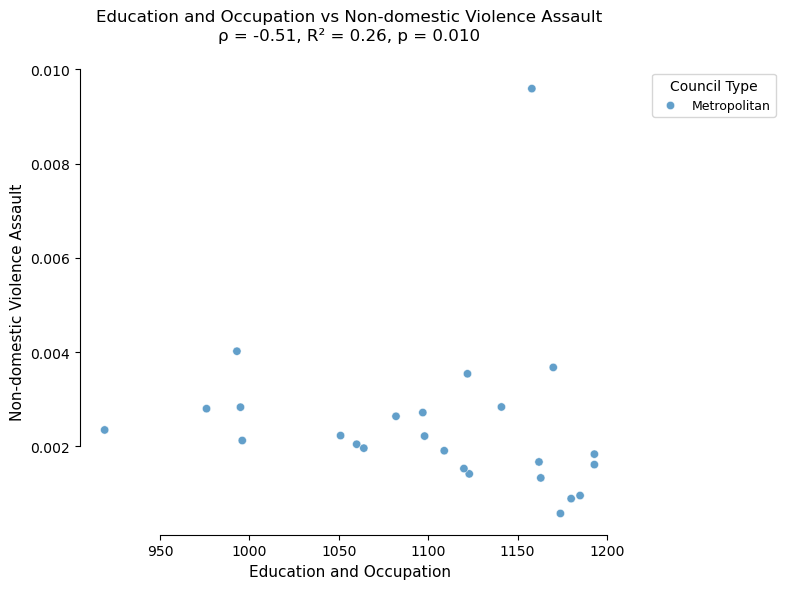

  - Education and Occupation vs Non-domestic Violence Assault: Correlation is significant (p=0.0099)

Analyzing correlation for Education and Occupation and Assault on Police


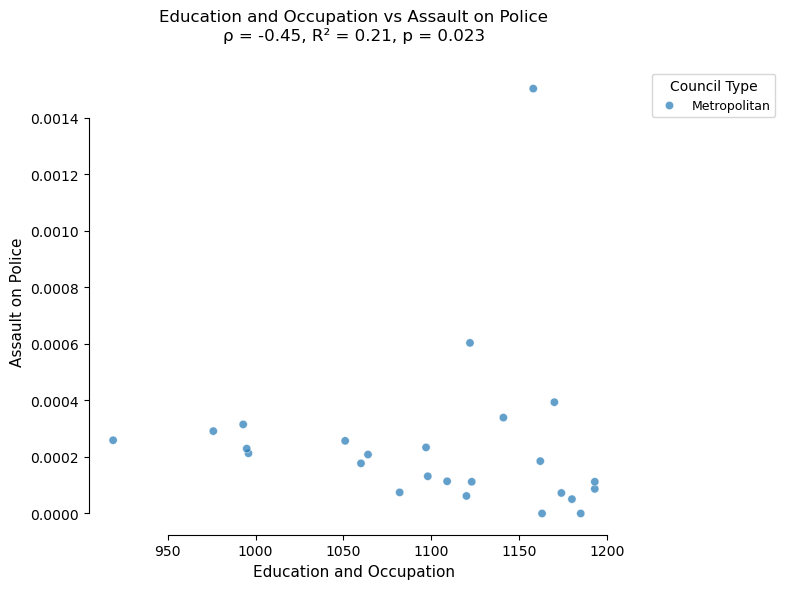

  - Education and Occupation vs Assault on Police: Correlation is significant (p=0.0226)

Analyzing correlation for Education and Occupation and Sexual Assault


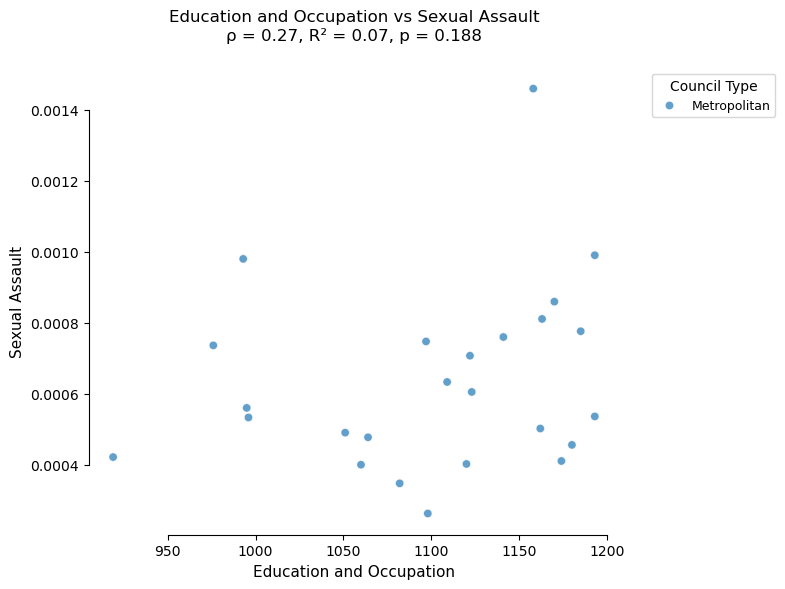

  - Education and Occupation vs Sexual Assault: Correlation is not significant (p=0.1878)

Analyzing correlation for Education and Occupation and Sexual Offences


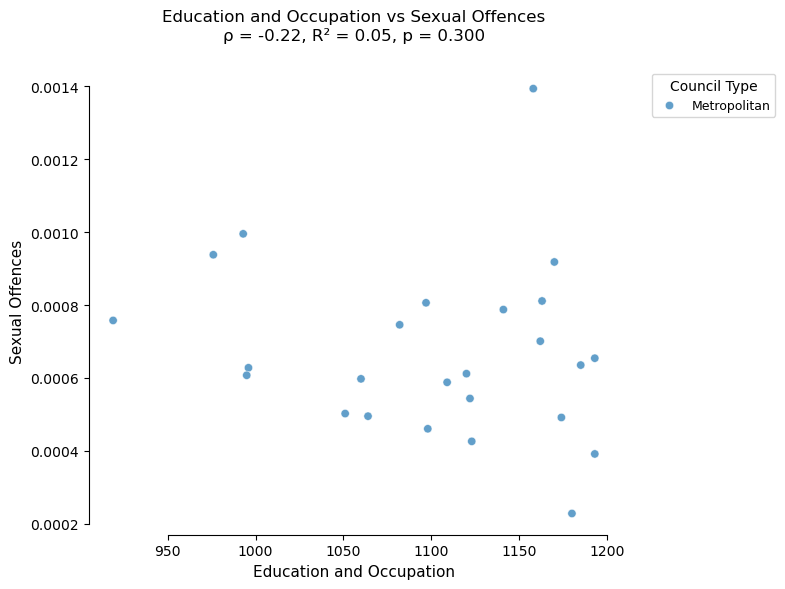

  - Education and Occupation vs Sexual Offences: Correlation is not significant (p=0.3002)

Analyzing correlation for Education and Occupation and Stalking and Harassment


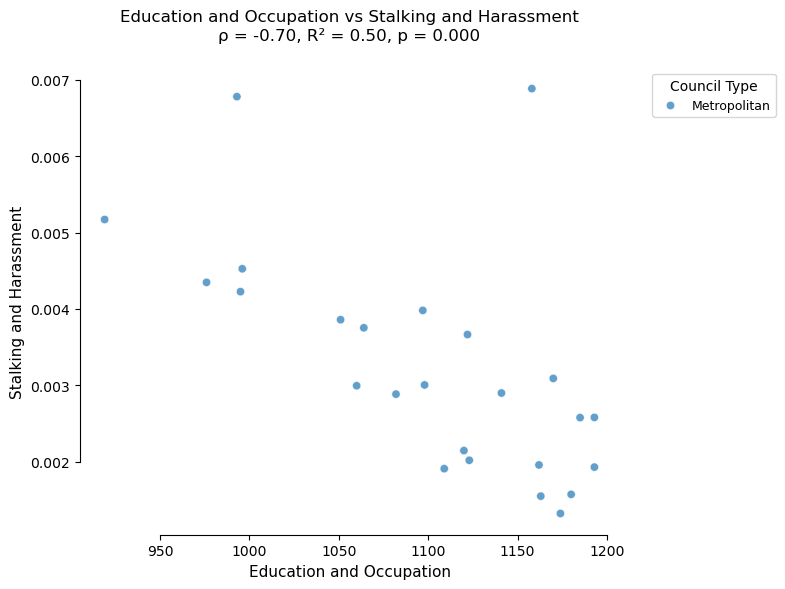

  - Education and Occupation vs Stalking and Harassment: Correlation is significant (p=0.0001)

Analyzing correlation for Male Mental Health Rate (0-34) and Male Mental Health Rate (>35)


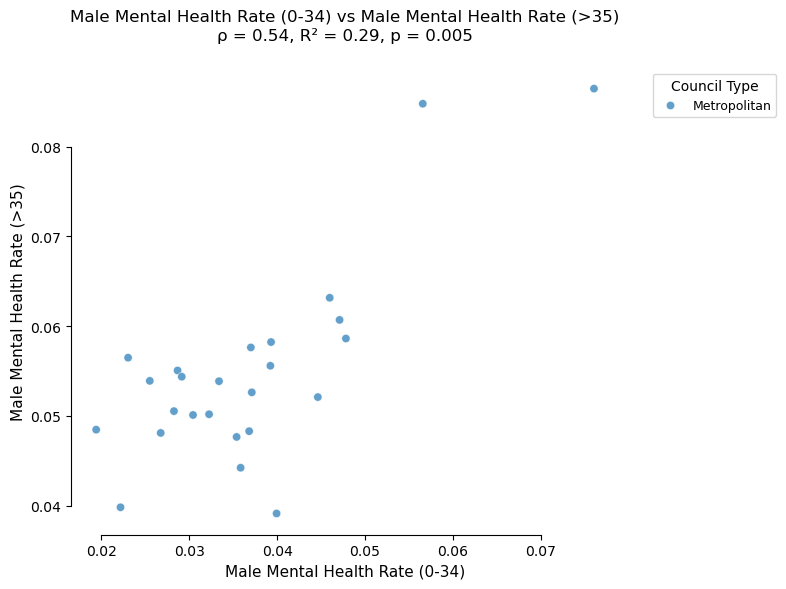

  - Male Mental Health Rate (0-34) vs Male Mental Health Rate (>35): Correlation is significant (p=0.0051)

Analyzing correlation for Male Mental Health Rate (0-34) and Female Mental Health Rate (0-34)


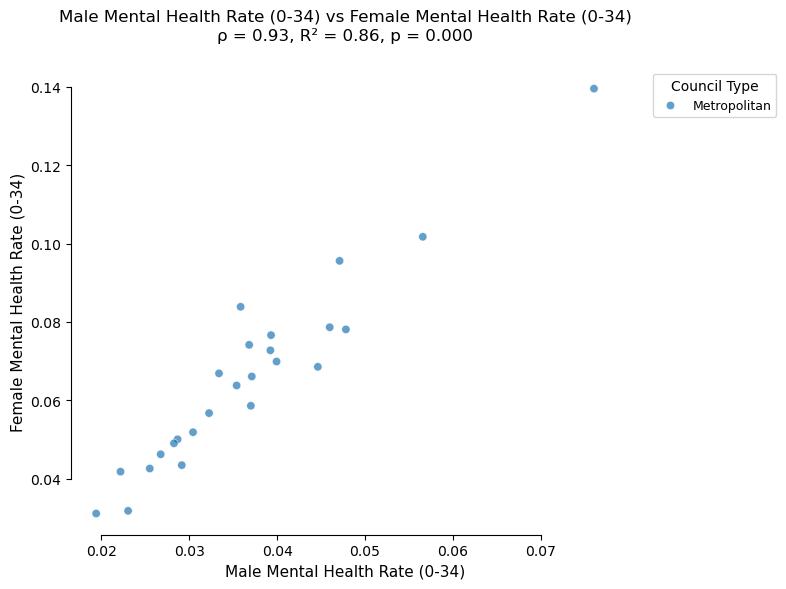

  - Male Mental Health Rate (0-34) vs Female Mental Health Rate (0-34): Correlation is significant (p=0.0000)

Analyzing correlation for Male Mental Health Rate (0-34) and Female Mental Health Rate (>35)


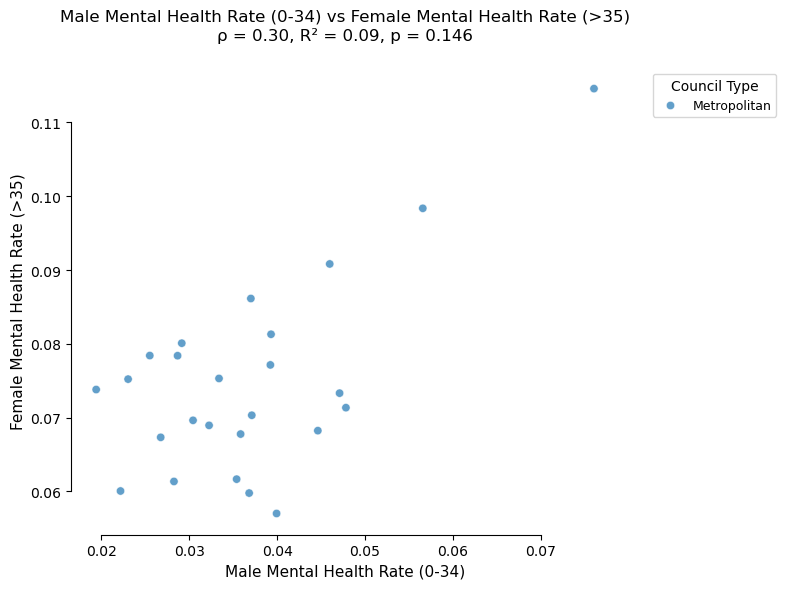

  - Male Mental Health Rate (0-34) vs Female Mental Health Rate (>35): Correlation is not significant (p=0.1462)

Analyzing correlation for Male Mental Health Rate (0-34) and Domestic Violence Assault


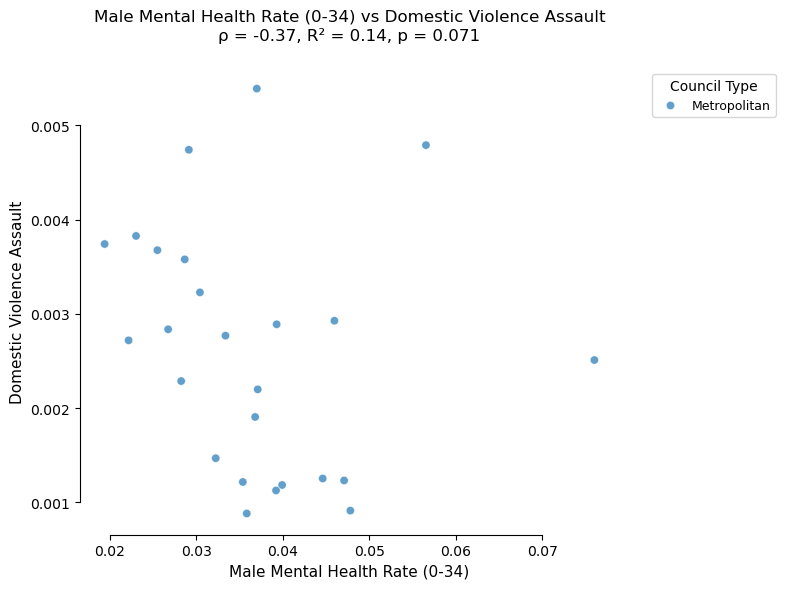

  - Male Mental Health Rate (0-34) vs Domestic Violence Assault: Correlation is not significant (p=0.0706)

Analyzing correlation for Male Mental Health Rate (0-34) and Non-domestic Violence Assault


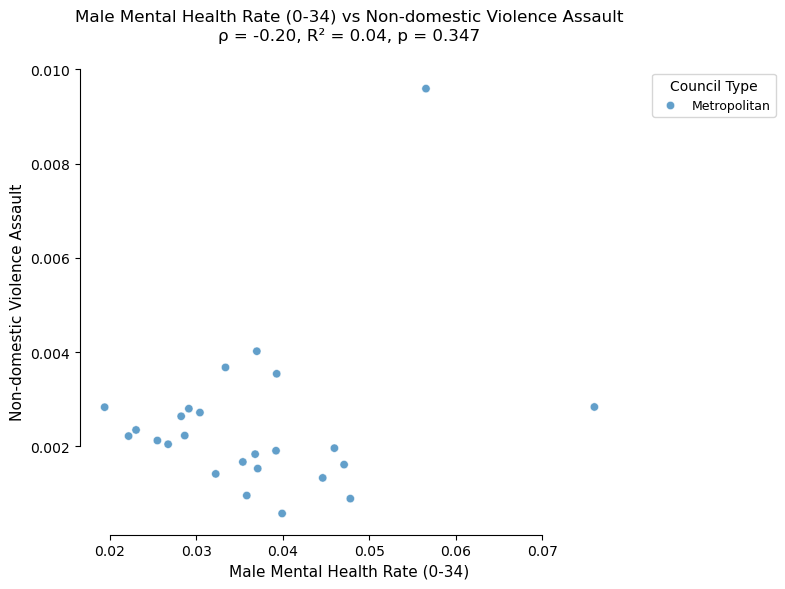

  - Male Mental Health Rate (0-34) vs Non-domestic Violence Assault: Correlation is not significant (p=0.3474)

Analyzing correlation for Male Mental Health Rate (0-34) and Assault on Police


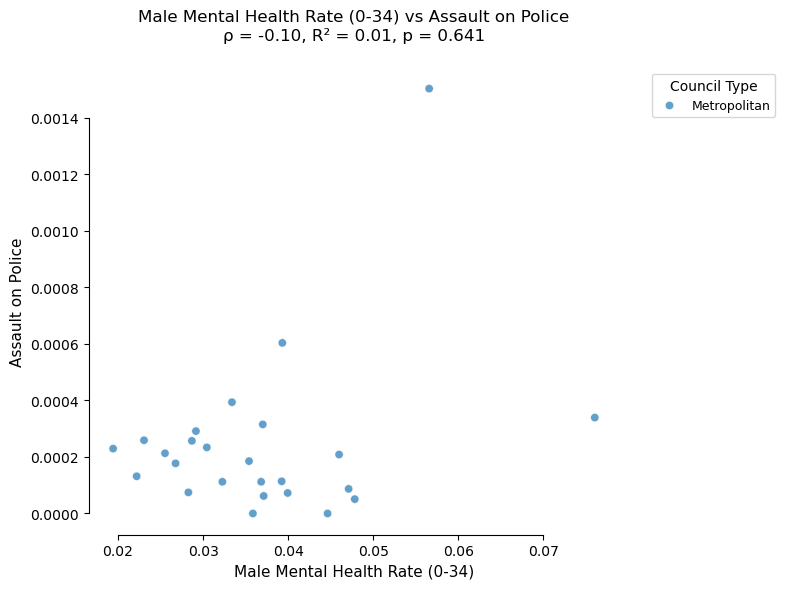

  - Male Mental Health Rate (0-34) vs Assault on Police: Correlation is not significant (p=0.6409)

Analyzing correlation for Male Mental Health Rate (0-34) and Sexual Assault


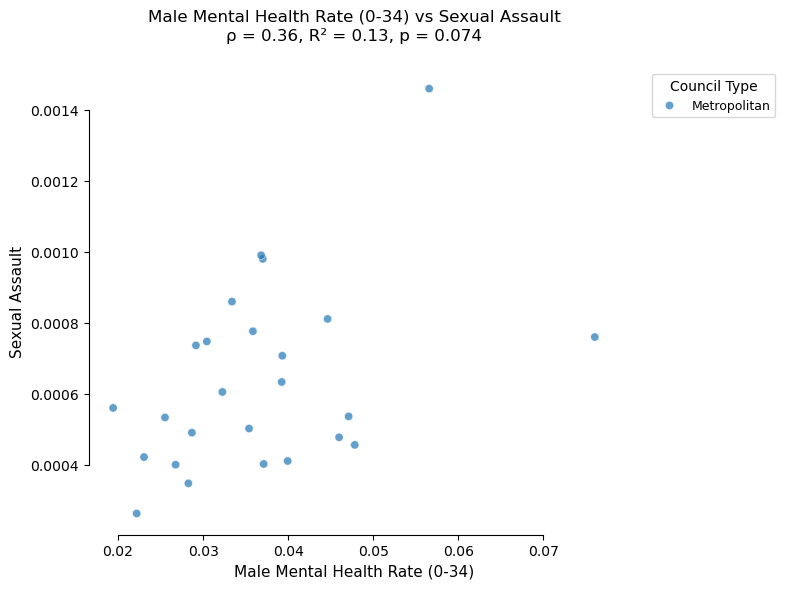

  - Male Mental Health Rate (0-34) vs Sexual Assault: Correlation is not significant (p=0.0738)

Analyzing correlation for Male Mental Health Rate (0-34) and Sexual Offences


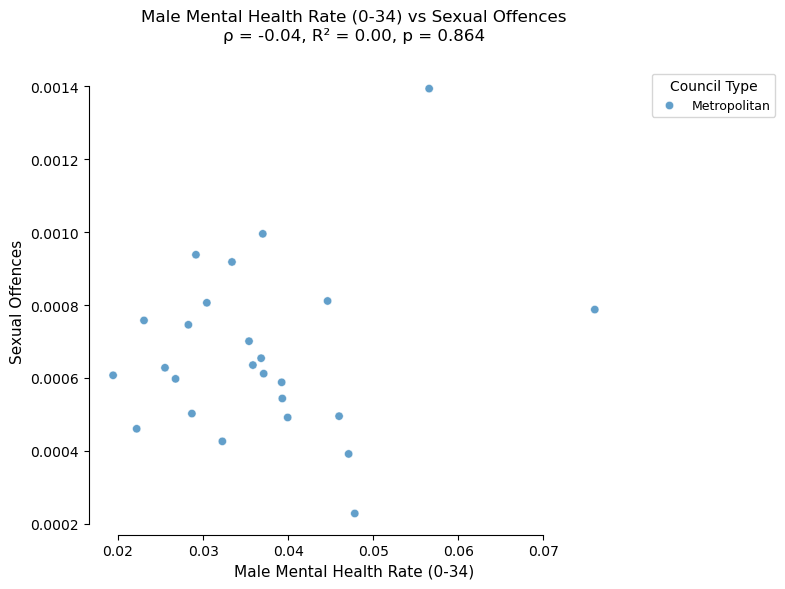

  - Male Mental Health Rate (0-34) vs Sexual Offences: Correlation is not significant (p=0.8638)

Analyzing correlation for Male Mental Health Rate (0-34) and Stalking and Harassment


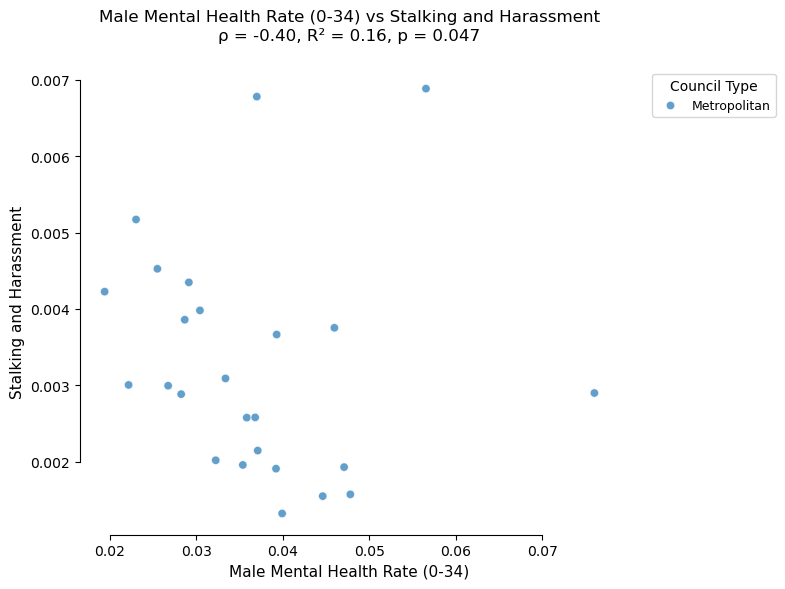

  - Male Mental Health Rate (0-34) vs Stalking and Harassment: Correlation is significant (p=0.0471)

Analyzing correlation for Male Mental Health Rate (>35) and Female Mental Health Rate (0-34)


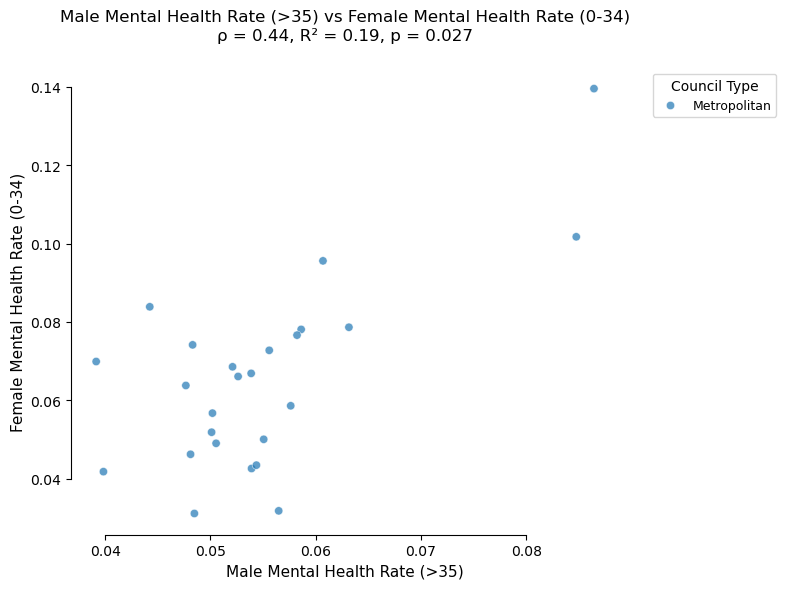

  - Male Mental Health Rate (>35) vs Female Mental Health Rate (0-34): Correlation is significant (p=0.0271)

Analyzing correlation for Male Mental Health Rate (>35) and Female Mental Health Rate (>35)


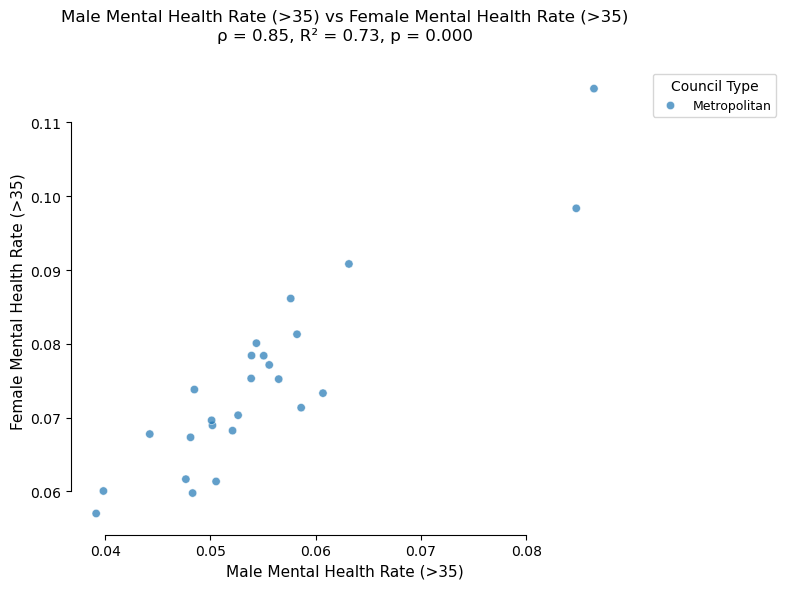

  - Male Mental Health Rate (>35) vs Female Mental Health Rate (>35): Correlation is significant (p=0.0000)

Analyzing correlation for Male Mental Health Rate (>35) and Domestic Violence Assault


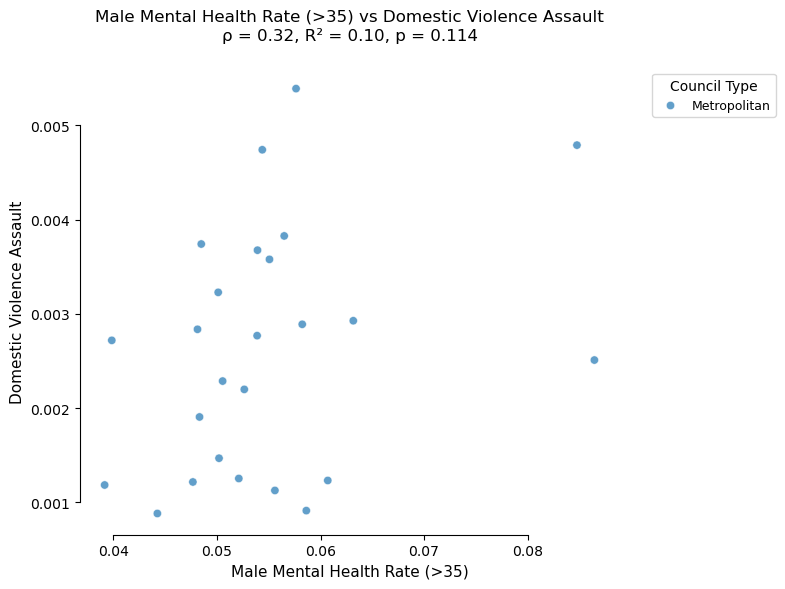

  - Male Mental Health Rate (>35) vs Domestic Violence Assault: Correlation is not significant (p=0.1143)

Analyzing correlation for Male Mental Health Rate (>35) and Non-domestic Violence Assault


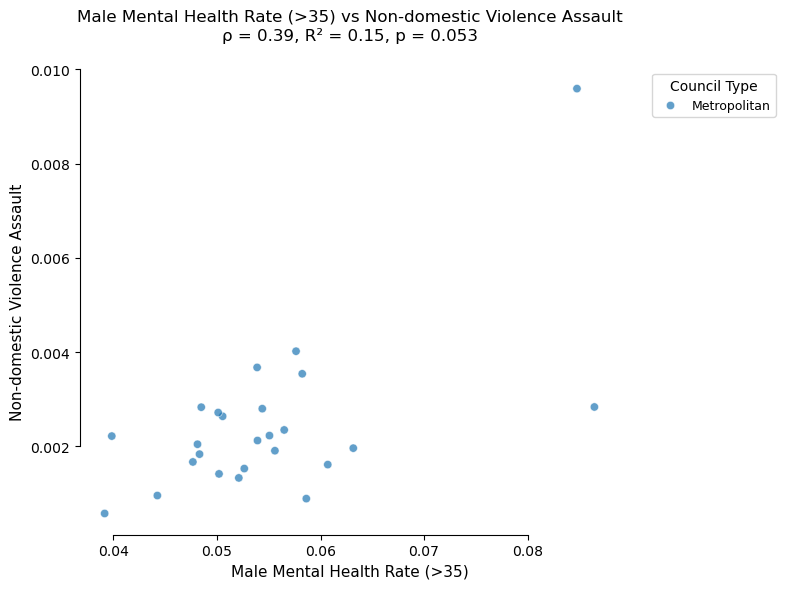

  - Male Mental Health Rate (>35) vs Non-domestic Violence Assault: Correlation is not significant (p=0.0534)

Analyzing correlation for Male Mental Health Rate (>35) and Assault on Police


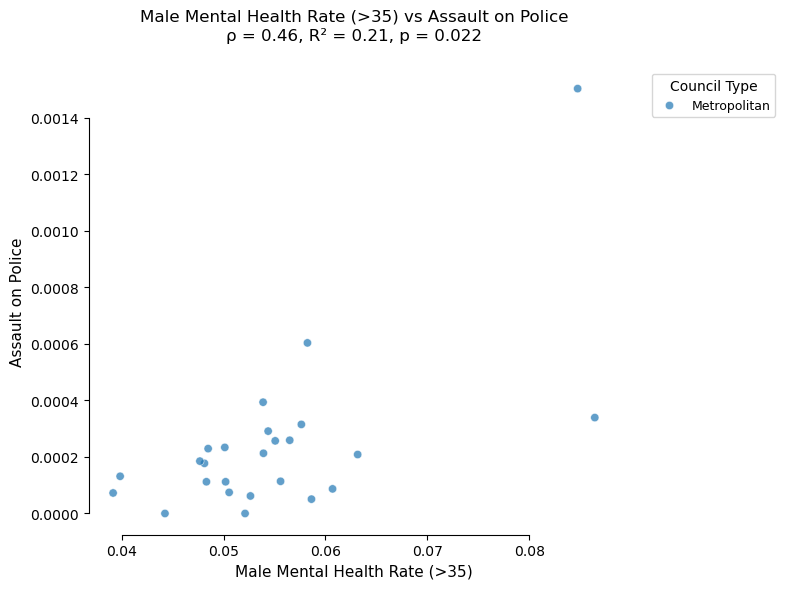

  - Male Mental Health Rate (>35) vs Assault on Police: Correlation is significant (p=0.0216)

Analyzing correlation for Male Mental Health Rate (>35) and Sexual Assault


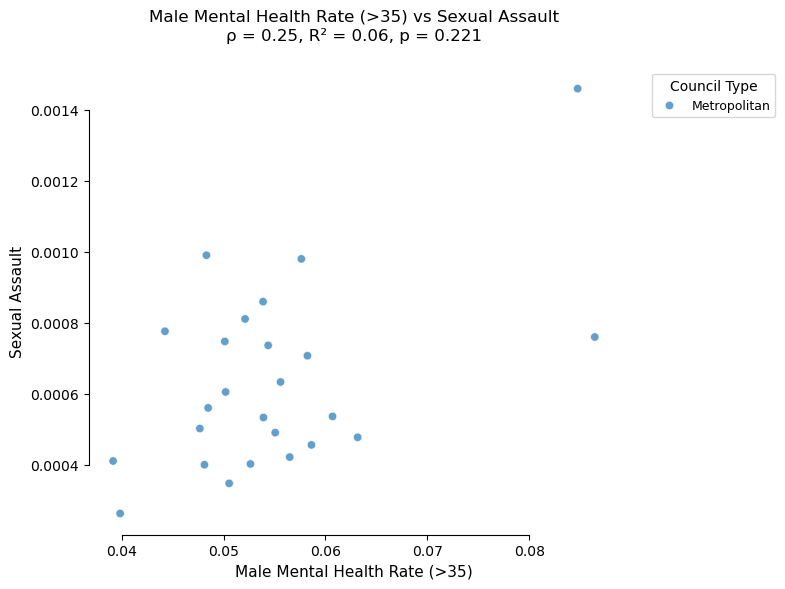

  - Male Mental Health Rate (>35) vs Sexual Assault: Correlation is not significant (p=0.2208)

Analyzing correlation for Male Mental Health Rate (>35) and Sexual Offences


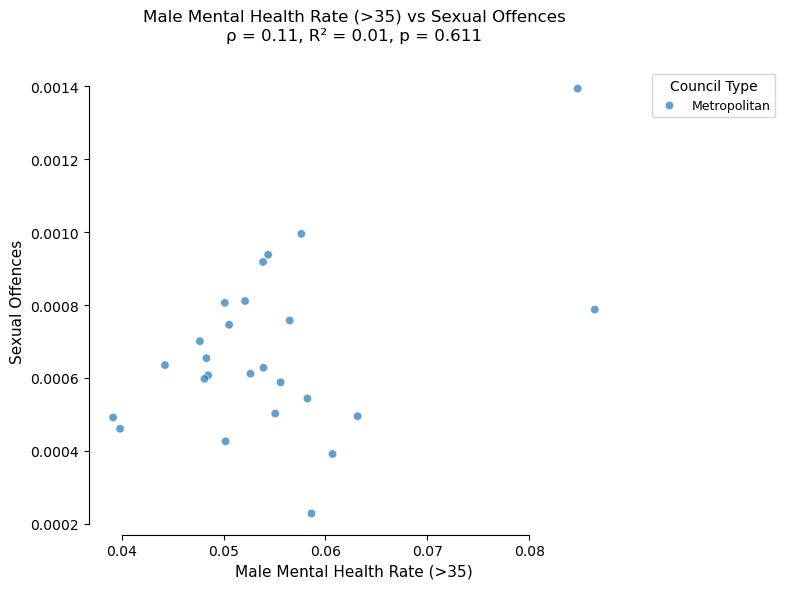

  - Male Mental Health Rate (>35) vs Sexual Offences: Correlation is not significant (p=0.6110)

Analyzing correlation for Male Mental Health Rate (>35) and Stalking and Harassment


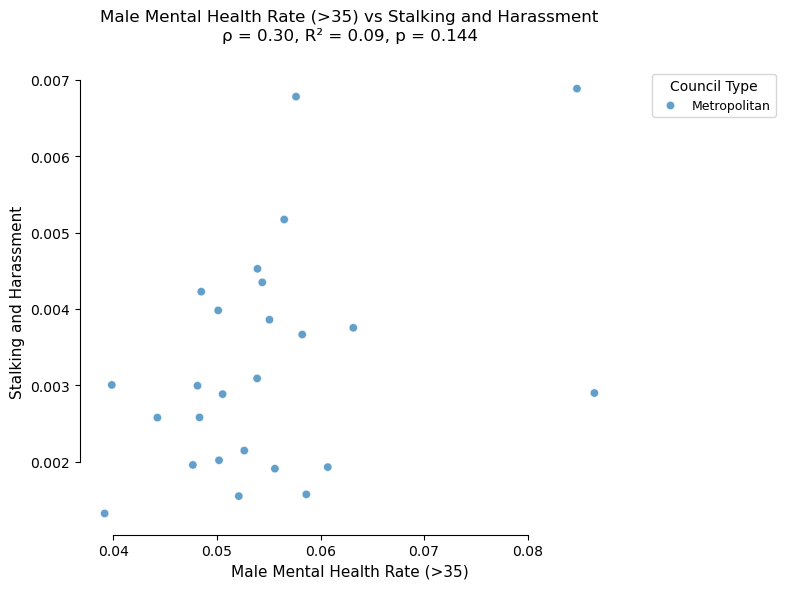

  - Male Mental Health Rate (>35) vs Stalking and Harassment: Correlation is not significant (p=0.1440)

Analyzing correlation for Female Mental Health Rate (0-34) and Female Mental Health Rate (>35)


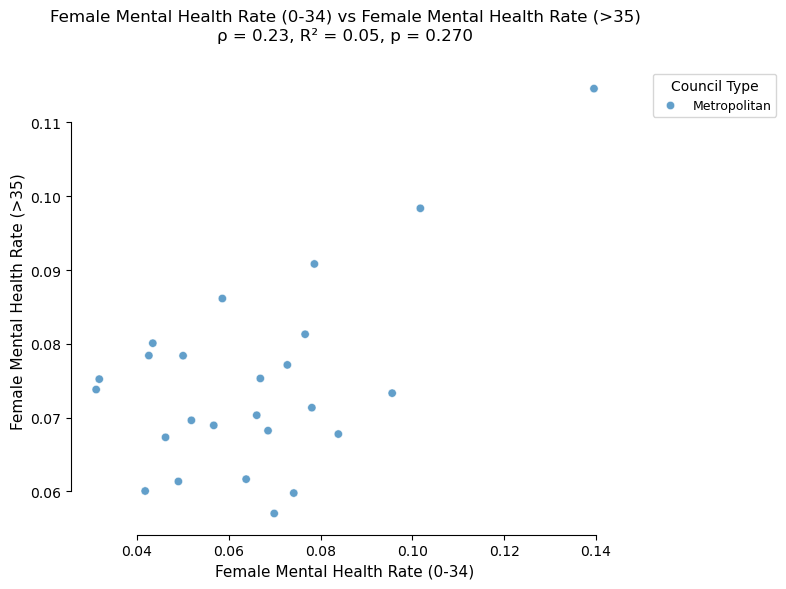

  - Female Mental Health Rate (0-34) vs Female Mental Health Rate (>35): Correlation is not significant (p=0.2704)

Analyzing correlation for Female Mental Health Rate (0-34) and Domestic Violence Assault


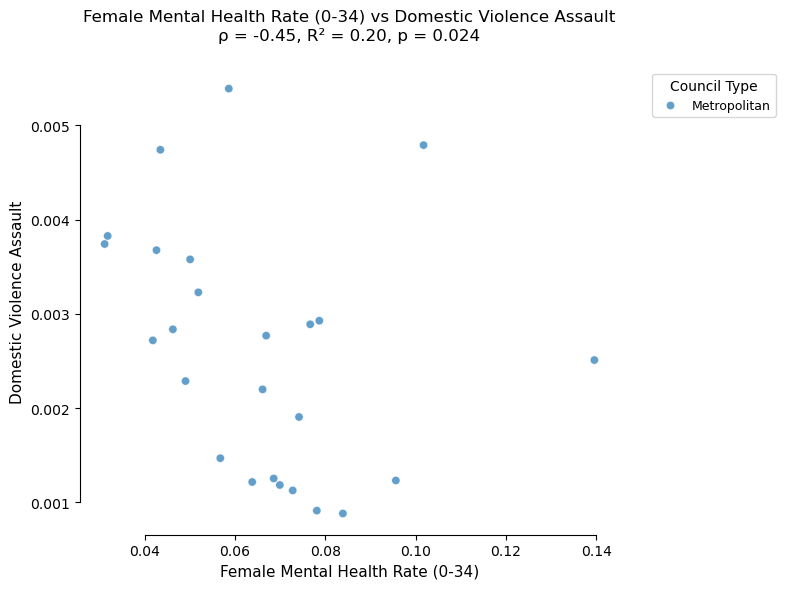

  - Female Mental Health Rate (0-34) vs Domestic Violence Assault: Correlation is significant (p=0.0240)

Analyzing correlation for Female Mental Health Rate (0-34) and Non-domestic Violence Assault


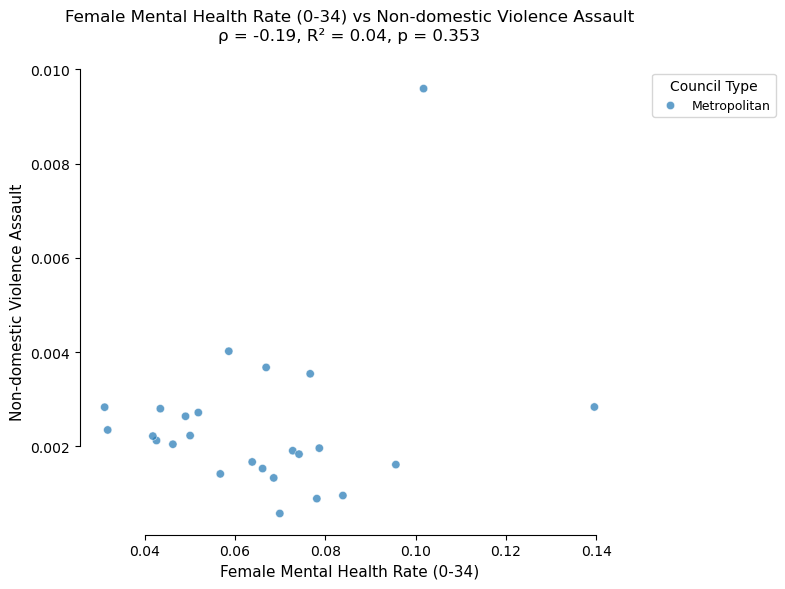

  - Female Mental Health Rate (0-34) vs Non-domestic Violence Assault: Correlation is not significant (p=0.3532)

Analyzing correlation for Female Mental Health Rate (0-34) and Assault on Police


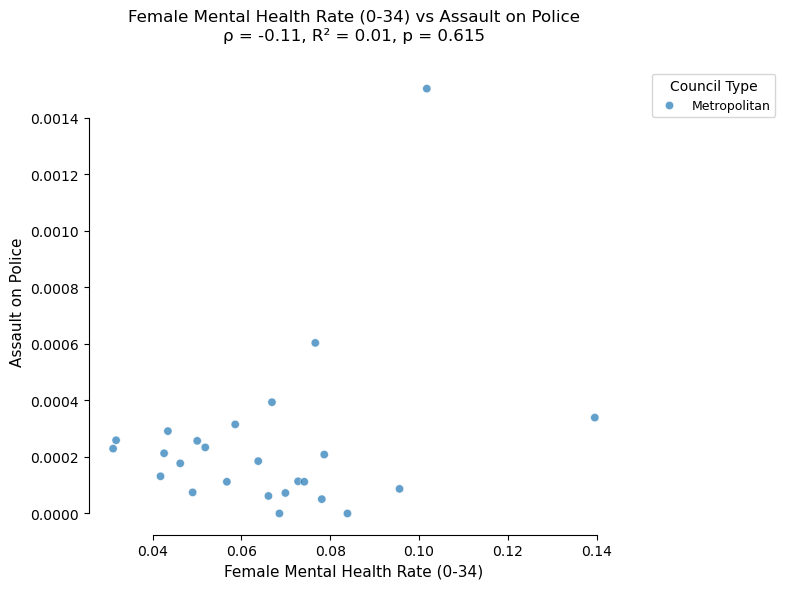

  - Female Mental Health Rate (0-34) vs Assault on Police: Correlation is not significant (p=0.6148)

Analyzing correlation for Female Mental Health Rate (0-34) and Sexual Assault


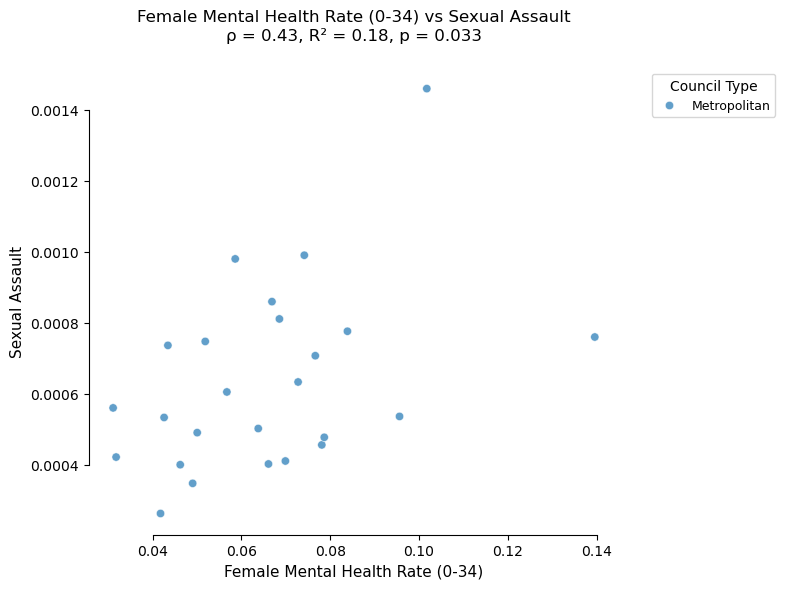

  - Female Mental Health Rate (0-34) vs Sexual Assault: Correlation is significant (p=0.0330)

Analyzing correlation for Female Mental Health Rate (0-34) and Sexual Offences


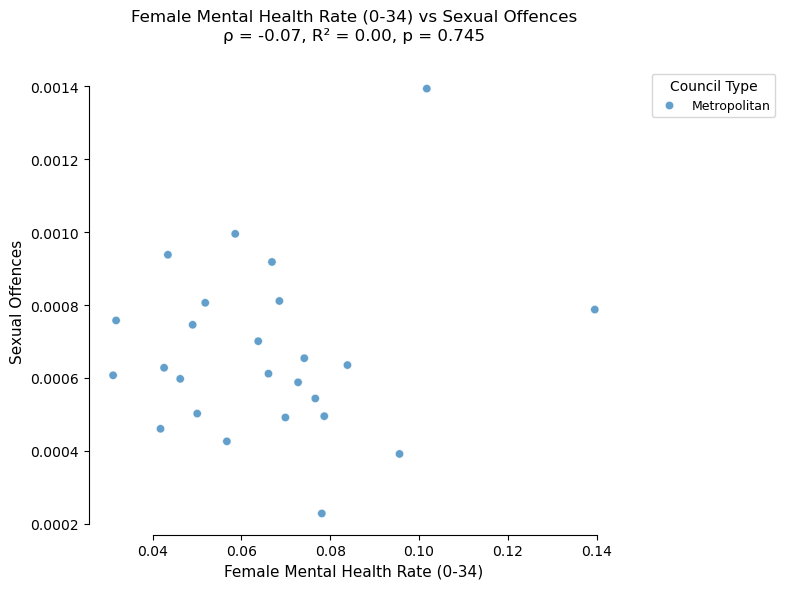

  - Female Mental Health Rate (0-34) vs Sexual Offences: Correlation is not significant (p=0.7451)

Analyzing correlation for Female Mental Health Rate (0-34) and Stalking and Harassment


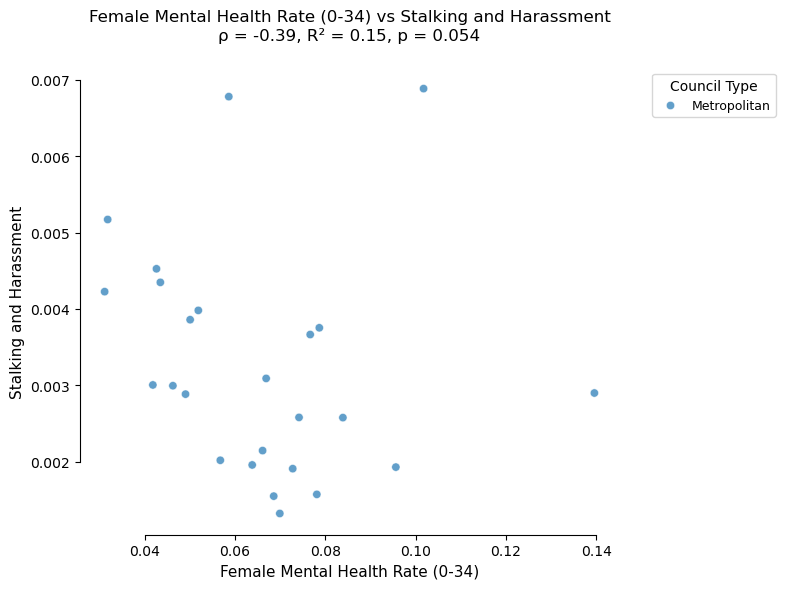

  - Female Mental Health Rate (0-34) vs Stalking and Harassment: Correlation is not significant (p=0.0545)

Analyzing correlation for Female Mental Health Rate (>35) and Domestic Violence Assault


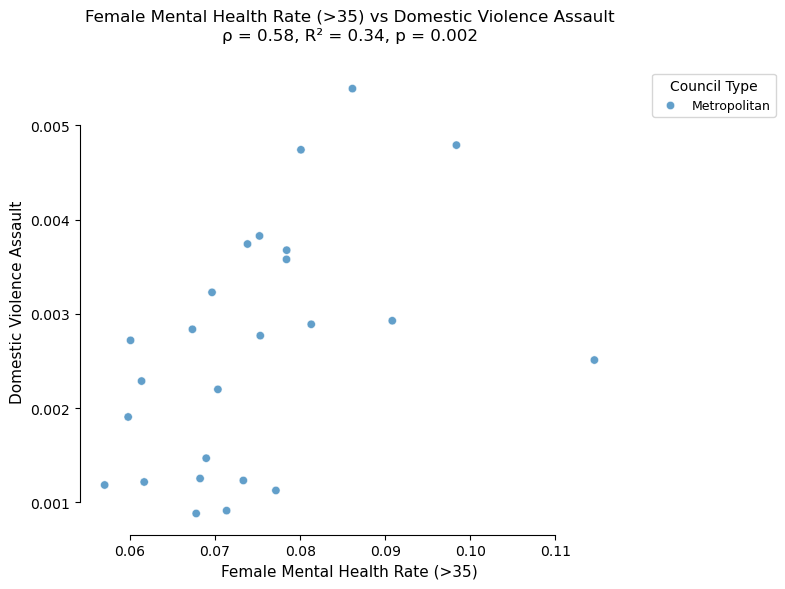

  - Female Mental Health Rate (>35) vs Domestic Violence Assault: Correlation is significant (p=0.0023)

Analyzing correlation for Female Mental Health Rate (>35) and Non-domestic Violence Assault


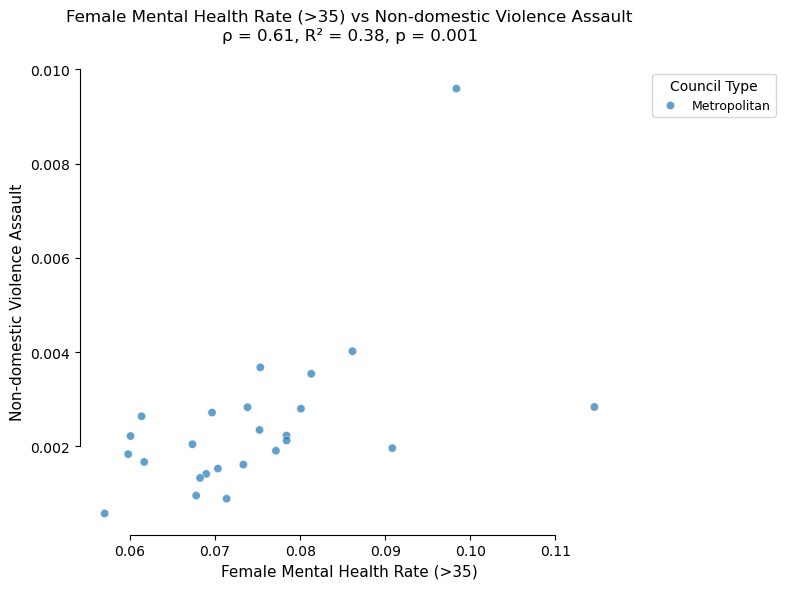

  - Female Mental Health Rate (>35) vs Non-domestic Violence Assault: Correlation is significant (p=0.0011)

Analyzing correlation for Female Mental Health Rate (>35) and Assault on Police


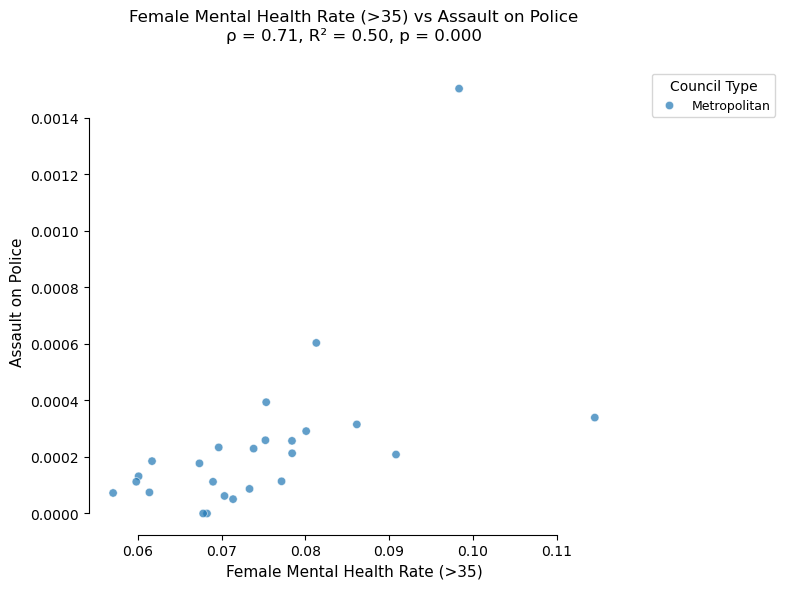

  - Female Mental Health Rate (>35) vs Assault on Police: Correlation is significant (p=0.0001)

Analyzing correlation for Female Mental Health Rate (>35) and Sexual Assault


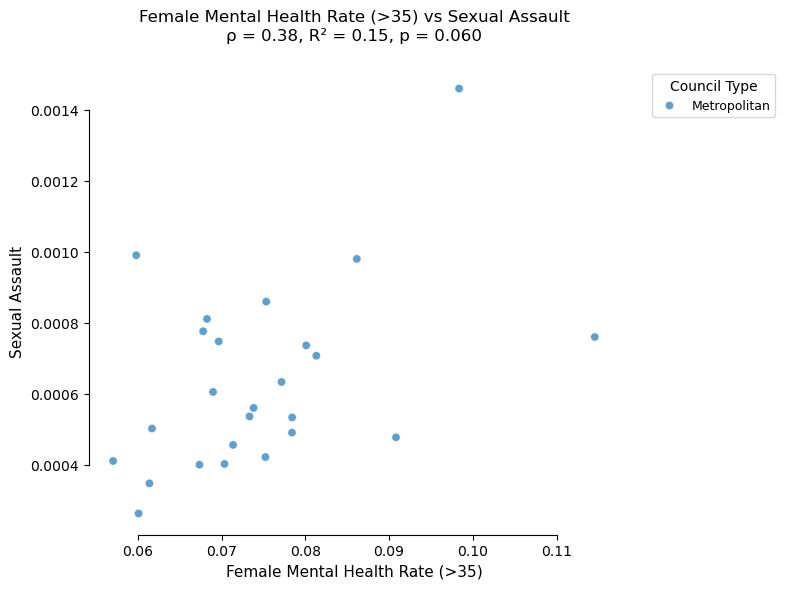

  - Female Mental Health Rate (>35) vs Sexual Assault: Correlation is not significant (p=0.0598)

Analyzing correlation for Female Mental Health Rate (>35) and Sexual Offences


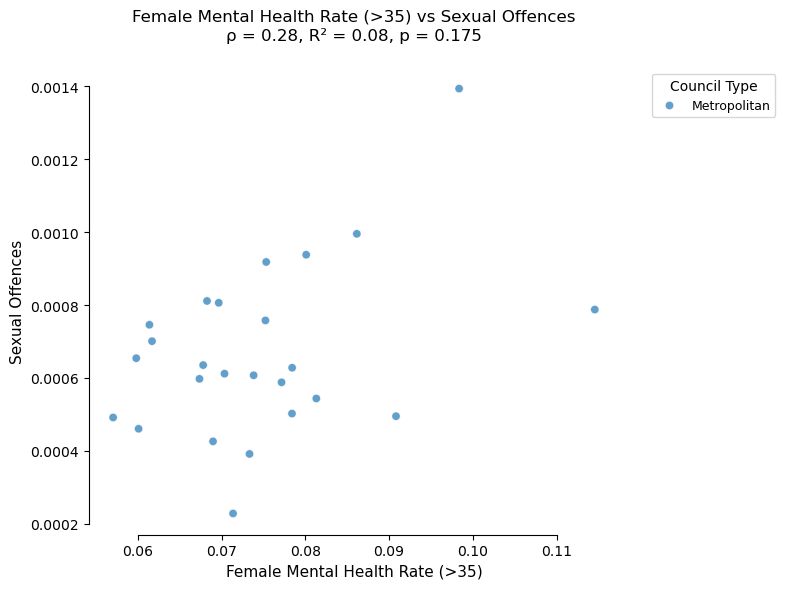

  - Female Mental Health Rate (>35) vs Sexual Offences: Correlation is not significant (p=0.1752)

Analyzing correlation for Female Mental Health Rate (>35) and Stalking and Harassment


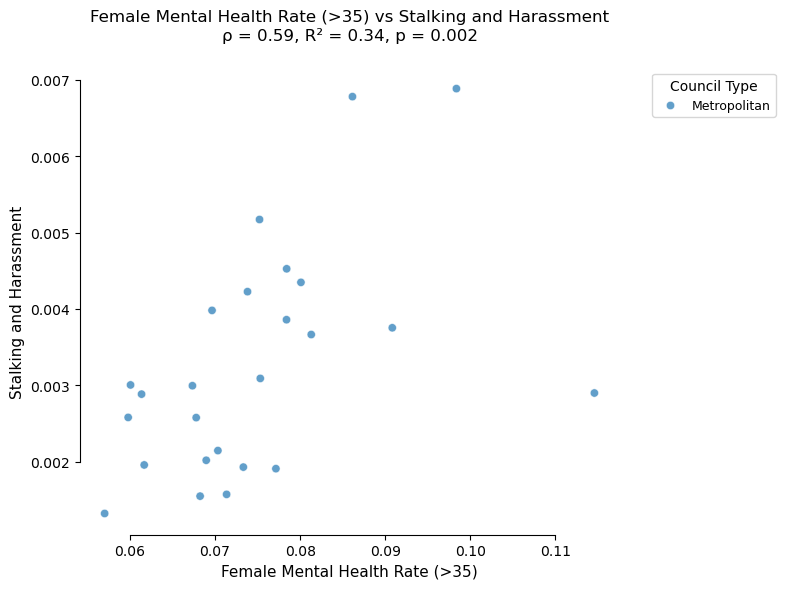

  - Female Mental Health Rate (>35) vs Stalking and Harassment: Correlation is significant (p=0.0021)

Analyzing correlation for Domestic Violence Assault and Non-domestic Violence Assault


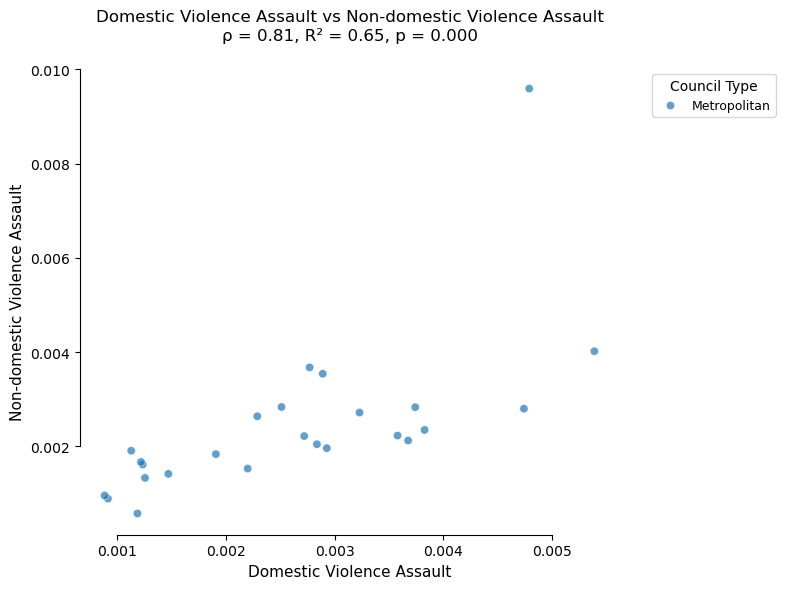

  - Domestic Violence Assault vs Non-domestic Violence Assault: Correlation is significant (p=0.0000)

Analyzing correlation for Domestic Violence Assault and Assault on Police


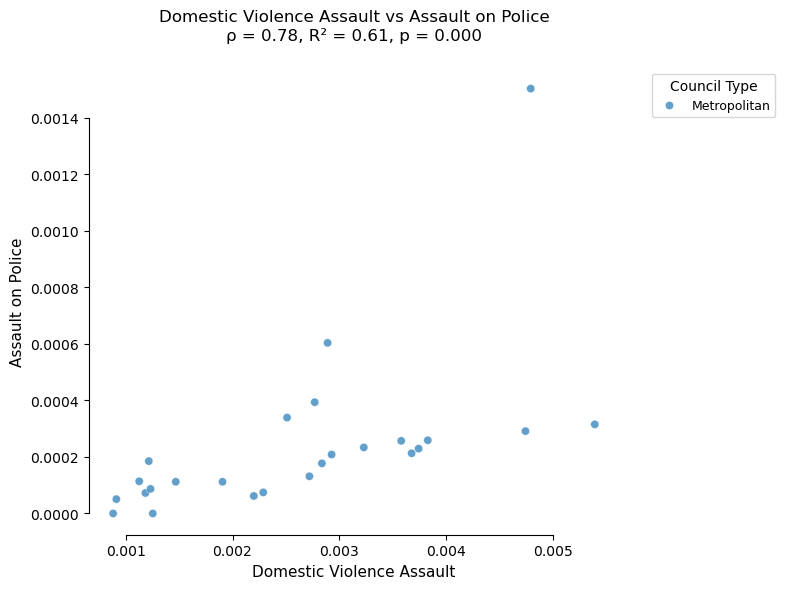

  - Domestic Violence Assault vs Assault on Police: Correlation is significant (p=0.0000)

Analyzing correlation for Domestic Violence Assault and Sexual Assault


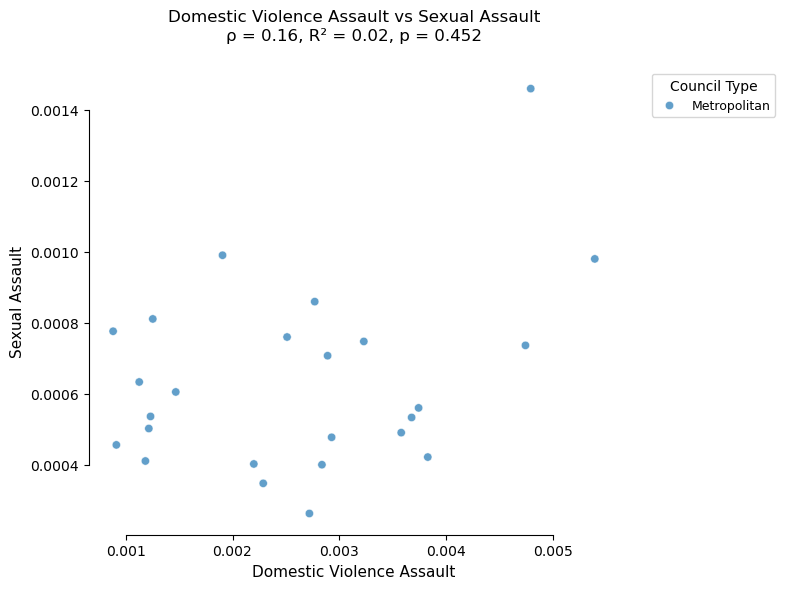

  - Domestic Violence Assault vs Sexual Assault: Correlation is not significant (p=0.4516)

Analyzing correlation for Domestic Violence Assault and Sexual Offences


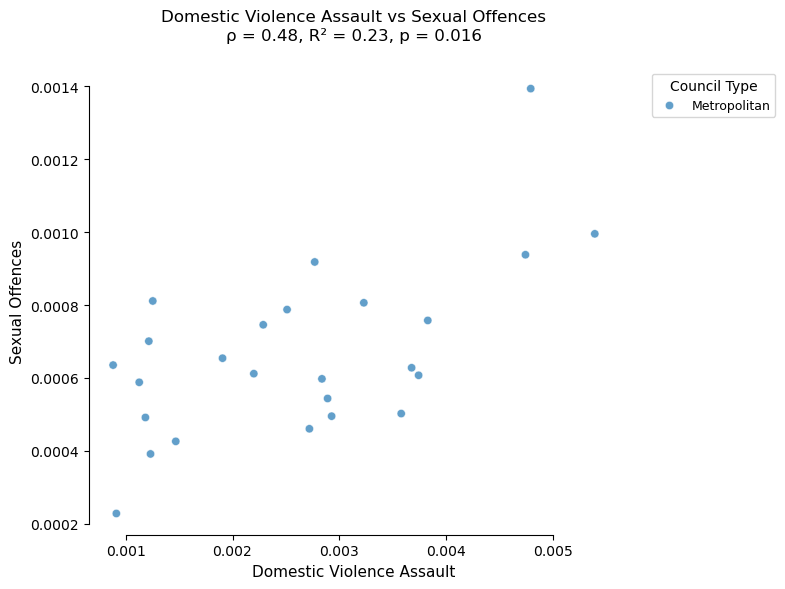

  - Domestic Violence Assault vs Sexual Offences: Correlation is significant (p=0.0159)

Analyzing correlation for Domestic Violence Assault and Stalking and Harassment


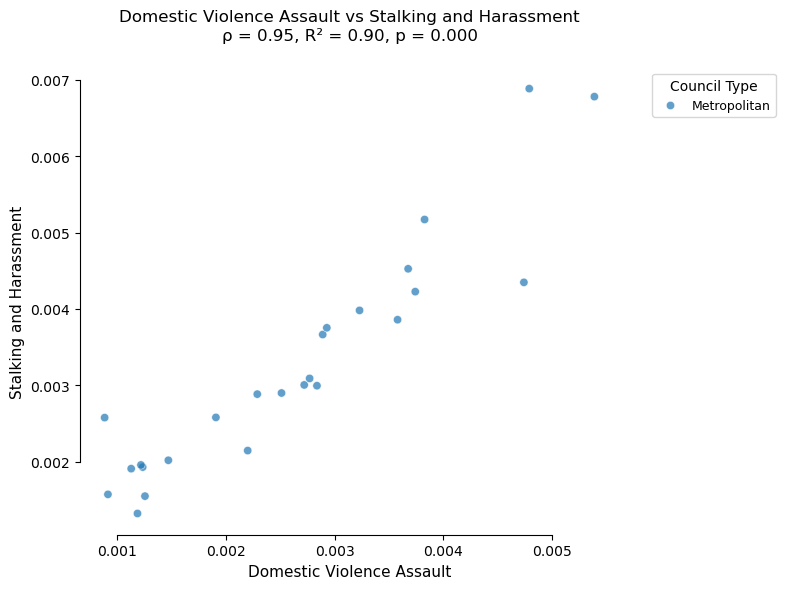

  - Domestic Violence Assault vs Stalking and Harassment: Correlation is significant (p=0.0000)

Analyzing correlation for Non-domestic Violence Assault and Assault on Police


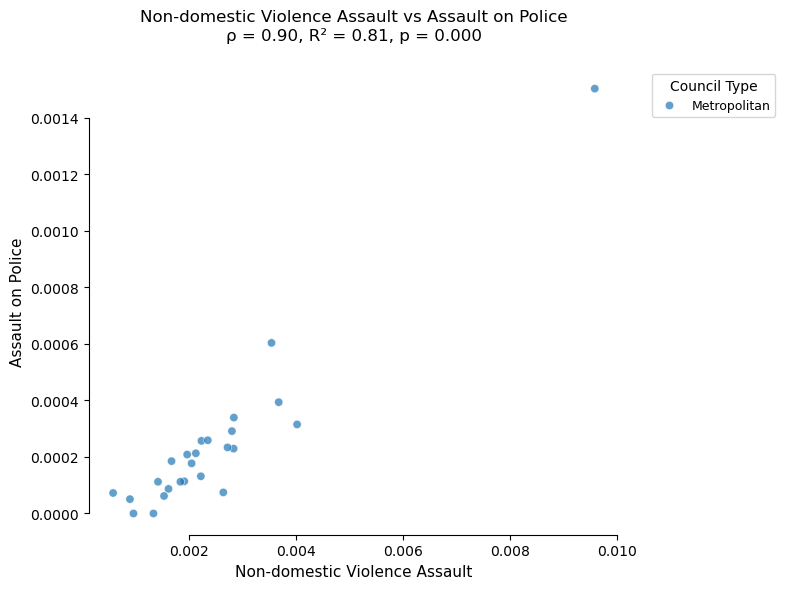

  - Non-domestic Violence Assault vs Assault on Police: Correlation is significant (p=0.0000)

Analyzing correlation for Non-domestic Violence Assault and Sexual Assault


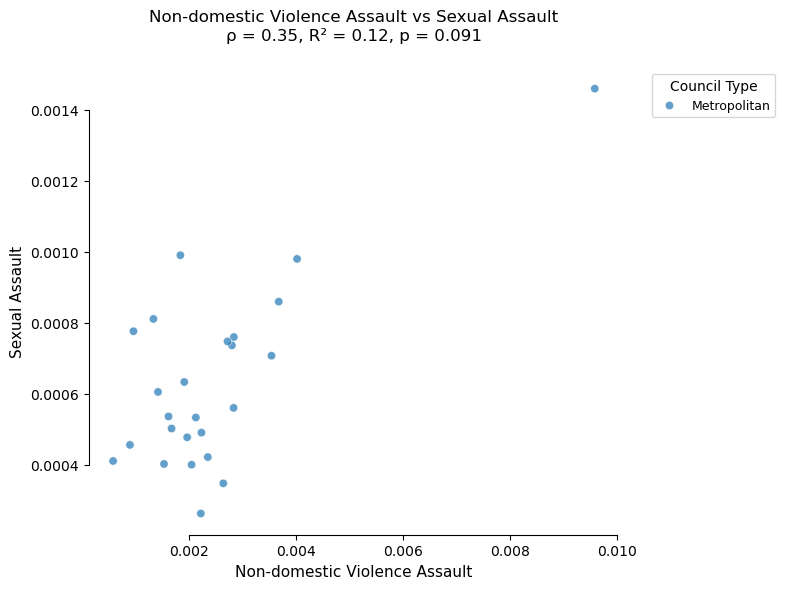

  - Non-domestic Violence Assault vs Sexual Assault: Correlation is not significant (p=0.0908)

Analyzing correlation for Non-domestic Violence Assault and Sexual Offences


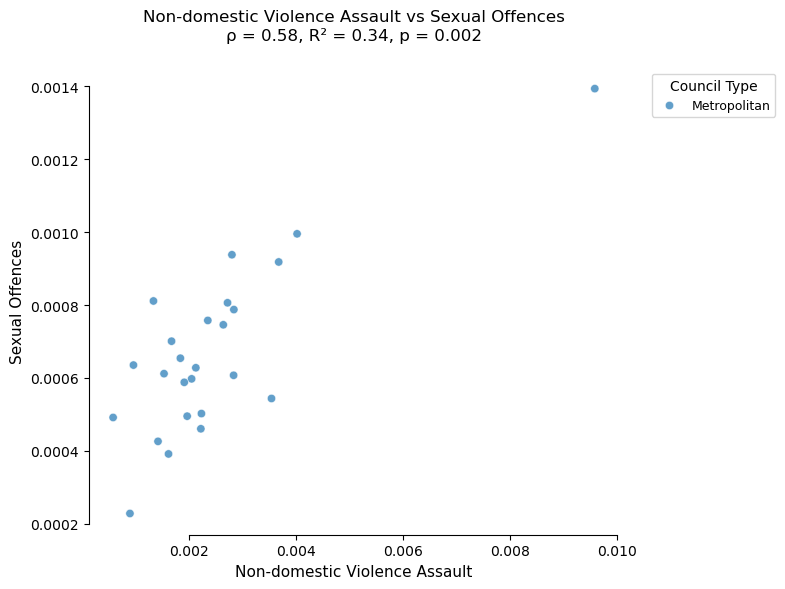

  - Non-domestic Violence Assault vs Sexual Offences: Correlation is significant (p=0.0024)

Analyzing correlation for Non-domestic Violence Assault and Stalking and Harassment


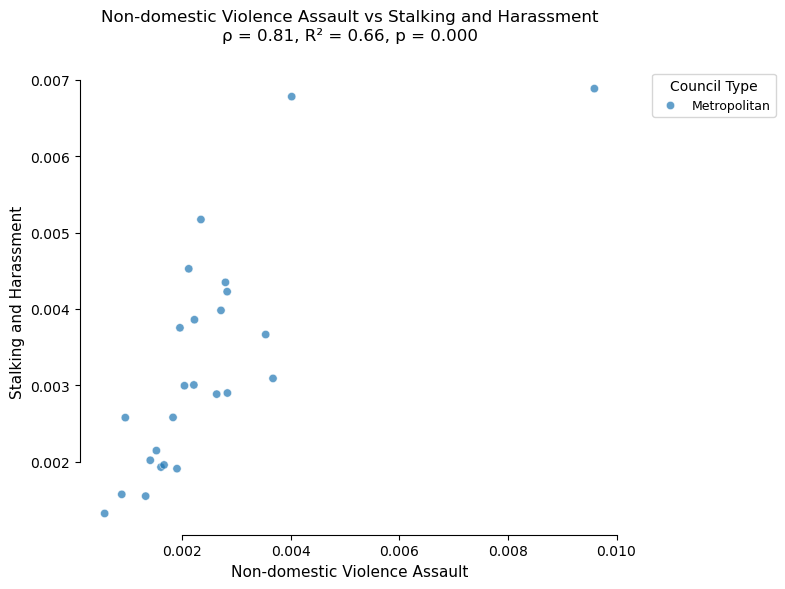

  - Non-domestic Violence Assault vs Stalking and Harassment: Correlation is significant (p=0.0000)

Analyzing correlation for Assault on Police and Sexual Assault


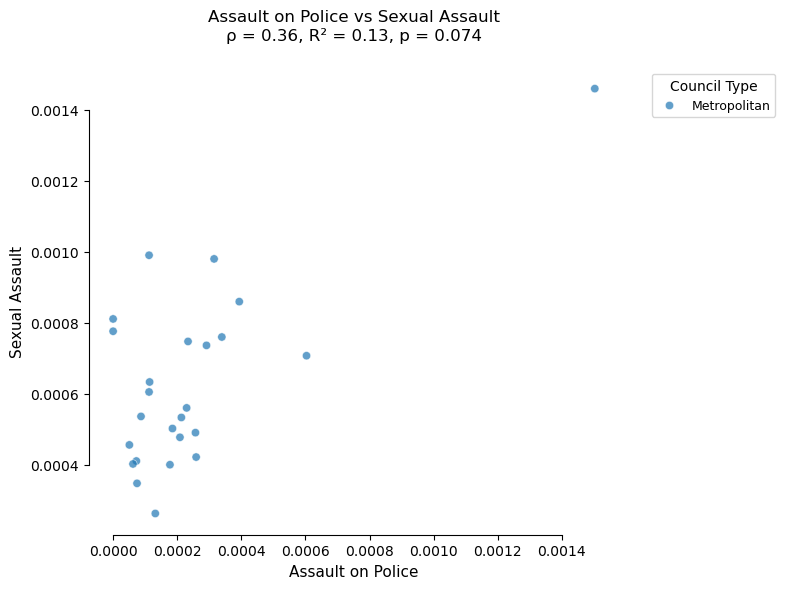

  - Assault on Police vs Sexual Assault: Correlation is not significant (p=0.0741)

Analyzing correlation for Assault on Police and Sexual Offences


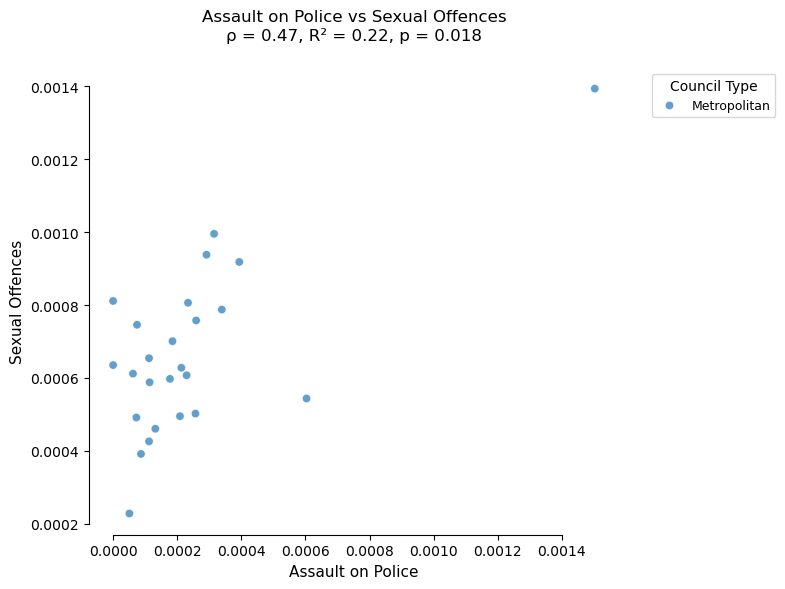

  - Assault on Police vs Sexual Offences: Correlation is significant (p=0.0183)

Analyzing correlation for Assault on Police and Stalking and Harassment


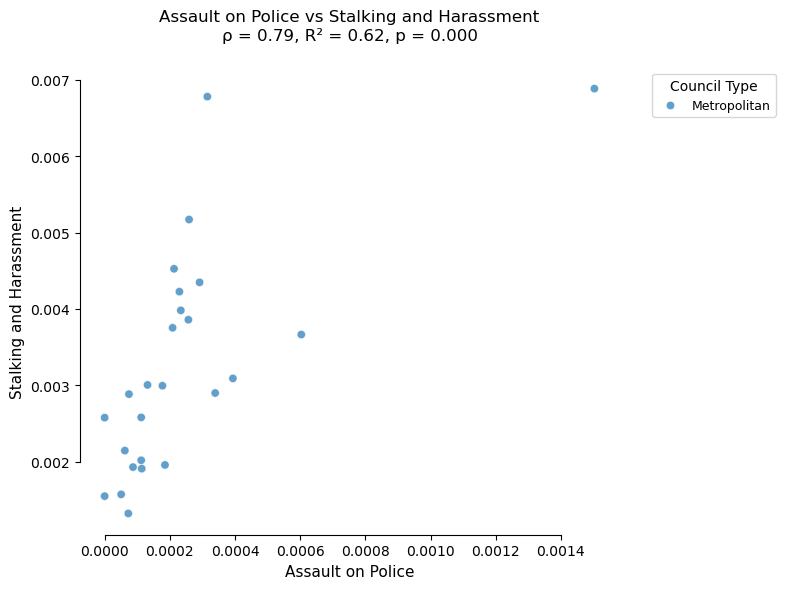

  - Assault on Police vs Stalking and Harassment: Correlation is significant (p=0.0000)

Analyzing correlation for Sexual Assault and Sexual Offences


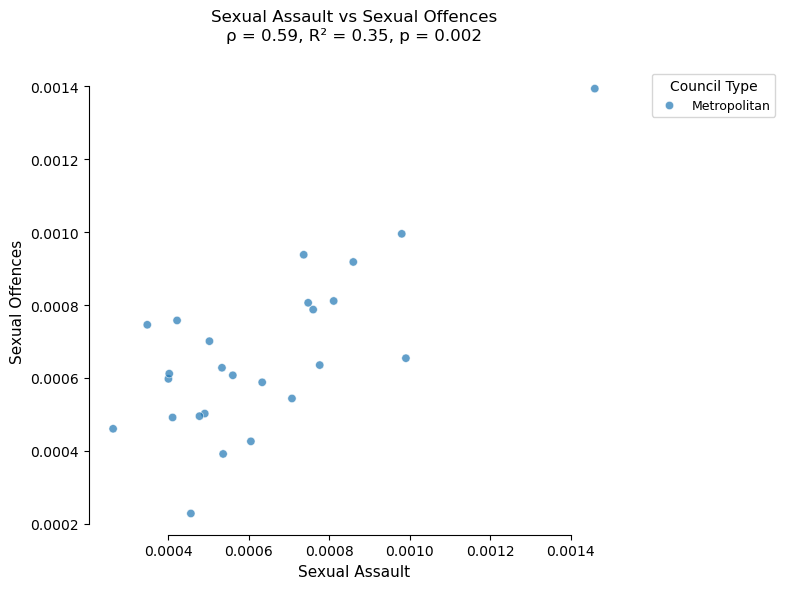

  - Sexual Assault vs Sexual Offences: Correlation is significant (p=0.0018)

Analyzing correlation for Sexual Assault and Stalking and Harassment


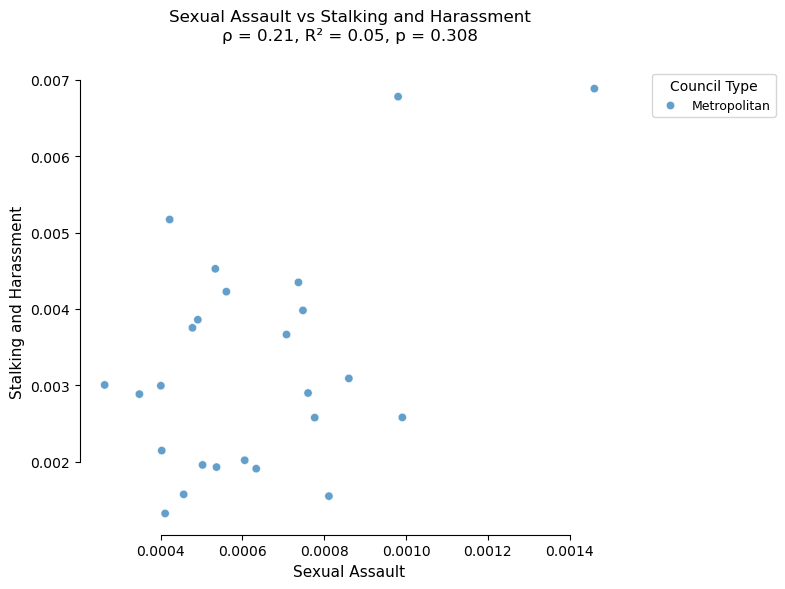

  - Sexual Assault vs Stalking and Harassment: Correlation is not significant (p=0.3083)

Analyzing correlation for Sexual Offences and Stalking and Harassment


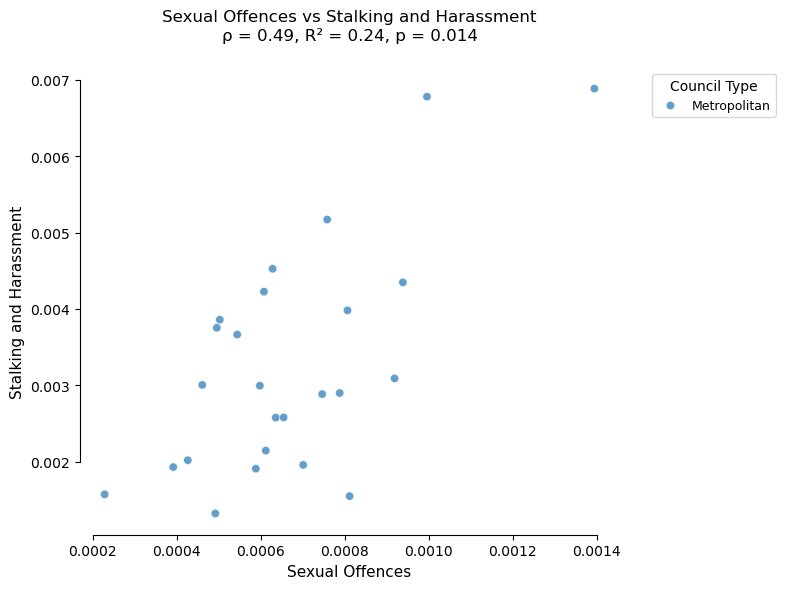

  - Sexual Offences vs Stalking and Harassment: Correlation is significant (p=0.0139)


In [31]:

# Define the variables as their raw names (this is what the actual dataframe uses)
variables = [
    'Socio-economic Disadvantage',
    'Socio-economic Advantage/Disadvantage',
    'Economic Resources',
    'Education and Occupation',
    'Male Mental Health Rate (0-34)',
    'Male Mental Health Rate (>35)',
    'Female Mental Health Rate (0-34)',
    'Female Mental Health Rate (>35)',
    'Domestic Violence Assault',
    'Non-domestic Violence Assault',
    'Assault on Police',
    'Sexual Assault',
    'Sexual Offences',
    'Stalking and Harassment'
]

def calculate_correlation(var1, var2, data):
    # Remove NaN values
    data_clean = data[[var1, var2]].dropna()
    # Normality assumption failed: Use Spearman's rank correlation
    corr, p_value = spearmanr(data_clean[var1], data_clean[var2])
    r_squared = corr ** 2  # Calculate R²
    
    # Create figure with APA-style formatting
    fig, ax = plt.subplots(figsize=(8, 6))

    # Create the scatter plot
    sns.scatterplot(data=data, x=var1, y=var2, hue='Council Type', 
                   ax=ax, alpha=0.7)  # Added slight transparency
    
    # Format title and labels according to APA style
    ax.set_title(f'{var1} vs {var2}\n'
                 f'ρ = {corr:.2f}, R² = {r_squared:.2f}, p = {p_value:.3f}',
                pad=20, fontsize=12)
    
    # Adjust axes labels with APA font size
    ax.set_xlabel(var1, fontsize=11)
    ax.set_ylabel(var2, fontsize=11)
    
    # Format legend
    ax.legend(title='Council Type', title_fontsize=10, fontsize=9,
             bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Add spines
    sns.despine(trim=True)  # Removes top and right spines
    
    # Adjust layout to prevent label cutoff
    plt.tight_layout()
    
    # Show plot
    plt.show()
    
    return corr, p_value

# Plot scatterplots for each pair of variables separated by 'Council Type'
for i, var1 in enumerate(variables):
    for var2 in variables[i+1:]:
        # Check if the variables have enough data points (e.g., no empty columns)
        if df_crime_health_seifa_council[var1].isnull().sum() == 0 and df_crime_health_seifa_council[var2].isnull().sum() == 0:
            print(f"\nAnalyzing correlation for {var1} and {var2}")

            # Calculate the correlation and display results
            corr, p_value = calculate_correlation(var1, var2, df_crime_health_seifa_council)

            # If correlation value is significant, display further information
            if p_value < 0.05:
                print(f"  - {var1} vs {var2}: Correlation is significant (p={p_value:.4f})")
            else:
                print(f"  - {var1} vs {var2}: Correlation is not significant (p={p_value:.4f})")
        else:
            print(f"  - Skipping {var1} vs {var2} due to missing data.")


#### Statistical Significance and Post-Hoc Tests

In [ ]:
# Load your dataset (replace with your actual data)
# df_crime_health_seifa_council = pd.read_csv("your_file.csv")

# List of quantitative variables
quantitative_vars = [
    'Socio-economic Disadvantage',
    'Socio-economic Advantage/Disadvantage',
    'Economic Resources',
    'Education and Occupation',
    'Male Mental Health Rate (0-34)',
    'Male Mental Health Rate (>35)',
    'Female Mental Health Rate (0-34)',
    'Female Mental Health Rate (>35)',
    'Domestic Violence Assault',
    'Non-domestic Violence Assault',
    'Assault on Police',
    'Sexual Assault',
    'Sexual Offences',
    'Stalking and Harassment'
]

# Categorical variable
categorical_var = 'Council Type'

# Loop through each quantitative variable
for var in quantitative_vars:
    print(f"\nAnalyzing variable: {var}")
    
    # Extract groups based on council type
    groups = [
        group[var].dropna() 
        for _, group in df_crime_health_seifa_council.groupby(categorical_var)
    ]
    
    # Step 1: Test for normality (Shapiro-Wilk test)
    normality_results = [shapiro(group) for group in groups if len(group) > 3]
    normality_pvalues = [res.pvalue for res in normality_results]
    if any(p < 0.05 for p in normality_pvalues):
        print(f"  - {var}: Data is not normally distributed (Shapiro-Wilk test failed).")
        # Proceed to Kruskal-Wallis if assumptions for both ANOVA and Welch's ANOVA fail
        kruskal_stat, kruskal_p = kruskal(*groups)
        df = len(groups) - 1  # Degrees of freedom
        if kruskal_p < 0.05:
            print(f"  - {var}: Kruskal-Wallis test is significant (H = {kruskal_stat:.4f}, df = {df}, p = {kruskal_p:.4f}).")
            # Perform Dunn's post-hoc test
            post_hoc = posthoc_dunn(
                df_crime_health_seifa_council,
                val_col=var,
                group_col=categorical_var,
                p_adjust='bonferroni'
            )
            print(f"  - Post-hoc results (Dunn's test):\n{post_hoc}")
        else:
            print(f"  - {var}: Kruskal-Wallis test is not significant (H = {kruskal_stat:.4f}, df = {df}, p = {kruskal_p:.4f}).")
        continue  # Skip to the next variable after Kruskal-Wallis
        
    # Step 2: Test for homogeneity of variances (Levene's test)
    levene_stat, levene_p = levene(*groups)
    if levene_p < 0.05:
        print(f"  - {var}: Variances are not equal (Levene's test failed).")
        # Perform Welch's ANOVA if variances are unequal
        welch_anova = anova_oneway(groups, use_var='unequal')
        if welch_anova.pvalue < 0.05:
            print(f"  - {var}: Welch's ANOVA is significant (p = {welch_anova.pvalue:.4f}).")
            # Perform Games-Howell post-hoc test
            post_hoc = pairwise_tukeyhsd(
                endog=df_crime_health_seifa_council[var],
                groups=df_crime_health_seifa_council[categorical_var],
                alpha=0.05
            )
            print(f"  - Post-hoc results (Games-Howell):\n{post_hoc}")
        else:
            print(f"  - {var}: Welch's ANOVA is not significant (p = {welch_anova.pvalue:.4f}).")
        continue  # Skip to the next variable after Welch's ANOVA
    
    # Step 3: Perform standard ANOVA
    anova_stat, anova_p = f_oneway(*groups)
    if anova_p < 0.05:
        df = len(groups) - 1  # Degrees of freedom
        print(f"  - {var}: ANOVA is significant (H = {anova_stat:.4f}, df = {df}, p = {anova_p:.4f}).")
        # Perform Tukey HSD post-hoc test
        post_hoc = pairwise_tukeyhsd(
            endog=df_crime_health_seifa_council[var],
            groups=df_crime_health_seifa_council[categorical_var],
            alpha=0.05
        )
        print(f"  - Post-hoc results (Tukey HSD):\n{post_hoc}")
    else:
        print(f"  - {var}: ANOVA is not significant (H = {anova_stat:.4f}, df = {df}, p = {anova_p:.4f}).")



Analyzing variable: Socio-economic Disadvantage


NameError: name 'df_crime_health_seifa_council' is not defined